# Описание проекта


**Аннотация**

Создание модели ML для прогнозирования числа заказов такси в аэропортах на следующий час.

---
**Задачи исследования**

Компания собрала исторические данные о заказах такси в аэропортах. Чтобы привлекать больше водителей в период пиковой нагрузки, нужно спрогнозировать количество заказов такси на следующий час. Необходимо построить модель ML для такого предсказания.

---
**Описание исходных данных**

Данные получаем из файла: `taxi.csv`.

*Краткое описание таблиц*
- Количество заказов находится в столбце num_orders (от англ. number of orders, «число заказов»).

---
**Ход исследования**:

1. О качестве данных ничего не известно, поэтому перед тем как приступать к исследованию, проводится общий обзор данных. Проводится проверка данных на ошибки/аномалии. На этапе предобработки данных анализируются возможности исправить ошибки/аномалии в данных, так, чтобы это не привело к искажению результатов исследования.

2. Производится исследовательский и статистический анализ данных, анализируются наличие "выбросов" в данных и/или другие особенности. Производится анализ данных, по итогам которого будет сформирован набор входных признаков для моделей машинного обучения.

3. При необходимости:

- производится трансформация/преобразование существующих переменных;
- вводятся новые переменные;
- удаляются исходные переменные.

4. Построение модели ML: 
- Первый этап:
  - построение нескольких моделей прогноза, не подразумевающих машинного обучения;
  - это модели прогноза по предыдущим значениям временного ряда или статистические модели;
- Второй этап:
  - построение нескольких моделей прогноза  используя машинное обучение (ML);
  - выбор и обоснование целевой метрики качества прогноза;
- Второй этап:
  - сравнение результатов работы моделей и выбор лучшей модели;
  - проверка/тестирование лучшей модели ML;
  - если необходимо: улучшение/доработки лучшей модели ML.

5. Итоги и выводы:

- на лучшей модели ML предсказывается число заказов такси в аэропортах на следующий час;
- делаются выводы и рекомендации.

---
**Таким образом, исследование будет содержать следующие шаги**:

- Общий обзор данных;
- Предобработка данных;
- Исследовательский анализ данных;
- Общий анализ данных и формирование входных признаков для моделей ML;
- Построение модели машинного обучения для предсказания числа заказов такси в аэропортах на следующий час;
- Итоговые выводы, рекомендации, мнение аналитика.

# Импорт библиотек

In [1]:
# импорт библиотек
import os
import pandas as pd
import seaborn as sns
import numpy as np
import re
import math
import scipy.stats as stats
from scipy.stats import spearmanr, pearsonr
import random
import copy
import itertools
import warnings
# Подавляем предупреждения
warnings.filterwarnings(
    "ignore", message=".*observed=False.*"
    )
warnings.filterwarnings(
    "ignore", message=".*Non-invertible starting MA parameters found.*"
    )
warnings.filterwarnings(
    "ignore",
    message=".*ConvergenceWarning: Maximum Likelihood optimization failed to converge.*",
    )

import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
pd.options.display.float_format = '{:,.3f}'.format

from sklearn.metrics import make_scorer, mean_squared_error

from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import ElasticNet
from sklearn.ensemble import RandomForestRegressor

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, acf, pacf
import statsmodels.api as sm
import statsmodels.tsa.stattools as stattools
import statsmodels.graphics.tsaplots as tsaplots
from statsmodels.tsa.statespace.sarimax import SARIMAX

from IPython.display import display, Markdown, HTML
import pprint

# константы проекта

RANDOM_STATE = 99 # фикисруем для воспроизводимости

TEST_SIZE = 0.10  # размер тестовой выборки (от объема датасета)
# валидационной выборки нет - при обучении моделей будет применяться кросс-валидация

In [2]:
# Настройка размеров некоторых шрифтов для графиков
plt.rcParams.update({
    'axes.labelsize': 8,     # Размер шрифта меток осей (xlabel, ylabel)
    'xtick.labelsize': 7,    # Размер шрифта меток по оси X
    'ytick.labelsize': 7,    # Размер шрифта меток по оси Y
    'legend.fontsize': 7,    # Размер шрифта легенды
    'figure.titlesize': 10   # Размер шрифта заголовка графика
})

# Вспомогательные фукнции

## Функции: анализ датасета

In [5]:
# фукнция для вывода общих данных по таблице
def get_data_summary(df):
    """
    Создает сводную таблицу с информацией о данных в DataFrame.

    Вход:
    df (pd.DataFrame): Входной DataFrame

    Выход:
    pd.DataFrame: Таблица с информацией о каждом столбце:
                  - Название поля
                  - Количество пропущенных значений
                  - Процент пропущенных значений
                  - Количество уникальных значений
                  - Тип данных
    """
    summary = pd.DataFrame(
        {
            "Название поля": df.columns,
            "Пропуски в данных, шт.": [df[col].isna().sum() for col in df.columns],
            "% пропусков": [
                (df[col].isna().sum() / len(df) * 100).round(2) for col in df.columns
            ],
            "Уникальных значений, шт.": [df[col].nunique() for col in df.columns],
            "Тип данных": [df[col].dtype for col in df.columns]
        }
    )
    return summary

In [6]:
# фукнция для первичного просмотра и анализа данных в таблице
def df_data_first_view(df,
                       head_tail=True,
                       n_head=3,
                       n_tail=3,
                       duplicates=True,
                       sub_set_exclude=None,
                       summary=True,
                       unique_non_numeric=True):
    """
    Анализирует общие данные в DataFrame

    Вход:
    df : pd.DataFrame
        DataFrame для анализа
    head_tail : bool, default=True
        Маркер вывода первых и последних строк df
    n_head, n_tail: int, default=3
        Число ваыводимых строк с начала и конца df
    duplicates : bool, default=True
        Маркер анализа и вывода статистики по явным дубликатам в df
    sub_set_exclude : list, default=None
        Списк полей, которые нужно исключить при анализе явных дубликатов в df
    summary : bool, default=True
        Маркер анализа и вывода общей статистики числовым по полям в df
    unique_non_numeric : bool, default=True
        Маркер анализа и вывода уникальных значений по нечисловым полям в df

    Возвращает:
    None (выводит отчет в Jupyter Notebook)
    """

    if head_tail:
        # первые и последние строки датасета
        n_head = max(n_head, 3)
        n_tail = max(n_tail, 3)

        print(f"Первые {n_head} и последние {n_tail} строк датасета")
        display(pd.concat([df.head(n_head), df.tail(n_tail)]))

    if summary:
        # создаем расширенную информацию о данных
        total_rows = len(df)
        non_null_counts = df.count()
        missing_counts = total_rows - non_null_counts
        unique_counts = df.nunique(dropna=False)
        dtypes_data = df.dtypes

        # итоговая таблица с информацией о данных
        extended_info = pd.DataFrame({
            'column': df.columns,
            'non-null_count': non_null_counts.values,
            'missing_count': missing_counts.values,
            'unique_count': unique_counts.values,
            'data_type': dtypes_data.values})

        # вывод расширенной информации о данных
        print('Информация о данных')
        display(extended_info)

    exclude_set = set(sub_set_exclude) if sub_set_exclude is not None else set()
    sub_set = [col for col in df.columns if col not in exclude_set]

    if duplicates:
        # подсчет числа и вывод на экран явных дубликатов
        total_duplicates = df.duplicated(subset=sub_set).sum()

        # считаем все строки, которые являются дубликатами (повторяются 2 и более раз)
        mask = df.duplicated(subset=sub_set, keep=False)
        total_duplicate_rows = mask.sum()

        if total_duplicates == 0:
            print(f"Явных дубликатов без учета полей "
                  f"{sub_set_exclude} нет")
        else:
            print(f"Анализ на дубликаты ВНЕ набора {sub_set_exclude}:")
            print(f"Число дубликатов (для для возможного удаления)             : "
                  f"{total_duplicates} шт.")
            print(f"Общее число дублирующихся строк (повторяются 2 и более раз): "
                  f"{total_duplicate_rows} шт.")

    # блок для вывода уникальных значений по нечисловым полям
    if unique_non_numeric:
        print("\n--- Уникальные значения для нечисловых полей ---")
        non_numeric_columns = df.select_dtypes(exclude=['number',
                                                        'datetime',
                                                        'timedelta']).columns
        if len(non_numeric_columns) == 0:
            print("Нечисловые столбцы отсутствуют.")
        else:
            for col in non_numeric_columns:
                unique_values = df[col].unique()
                print(f"\nСтолбец: '{col}'")
                print(f"Количество уникальных значений: {len(unique_values)}")
                print(f"Уникальные значения: {list(unique_values)}")
                result = df[col].value_counts().reset_index()
                result.columns = ['уникальное значение', 'число таких значений']
                result["% от общего числа записей"] = (
                    result["число таких значений"]
                    / result["число таких значений"].sum()
                    * 100
                ).round(2)
                display(result)
    return

## Функции: статистика, корреляции и т.п.

In [7]:
def check_normality(data, title="Анализ нормальности распределения",
                    figsize=(8, 3), title_fontsize=10):
    """
    Проверяет нормальность распределения данных с помощью теста Шапиро-Уилка
    и предоставляет дополнительную информацию о "близости" к нормальному.

    Вход:
    data (array-like): Одномерный массив данных (list, numpy.ndarray, pandas.Series).
    title (str): Общий заголовок для фигуры. По умолчанию "Анализ нормальности".
    figsize (tuple): Размер фигуры (ширина, высота). По умолчанию (9, 3).
    title_fontsize (int): Размер шрифта общего заголовка. По умолчанию 12.

    Выход:
    Печать результатов и визуализаций на экране.
    """
    # Преобразуем в pandas Series
    series = pd.Series(data)
    clean_data = series.dropna()

    # Проверим, достаточно ли данных для анализа, минимум для теста - 3 наблюдения
    if len(clean_data) < 3:
        print("Недостаточно данных для анализа (минимум 3).")
        return {'statistic': None, 'p_value': None, 'is_normal': False,
                'skewness': None, 'kurtosis': None}

    # Выполняем тест Шапиро-Уилка
    statistic, p_value = stats.shapiro(clean_data)

    # Рассчитываем асимметрию и эксцесс
    skewness = stats.skew(clean_data)
    kurtosis = stats.kurtosis(clean_data)

    # Решаем, нормальное ли распределение
    # (при p > 0.05 не отвергаем гиптезу о нормальности)
    is_normal = p_value > 0.05

    # Визуализация
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=figsize)
    fig.suptitle(title, fontsize=title_fontsize, y=0.95) # Уменьшаем отступ сверху

    # 1. Гистограмма
    ax1 = axes[0]
    # Рисуем только гистограмму без встроенной KDE
    sns.histplot(clean_data, stat='density', alpha=0.5,
                 bins=50, label='Гистограмма', ax=ax1)

    # Рассчитываем и рисуем KDE вручную с нужным цветом и меткой
    sns.kdeplot(clean_data, color='navy', linewidth=2,
                alpha=0.8, label='KDE', ax=ax1)

    # Плотность нормального распределения с теми же mean и std
    mu, sigma = clean_data.mean(), clean_data.std()
    x = np.linspace(clean_data.min(), clean_data.max(), 100)
    ax1.plot(x, stats.norm.pdf(x, mu, sigma),
             label=f'N~(μ={mu:.2f}, σ={sigma:.2f})',
             linestyle='--', color='darkred', alpha=0.8)
    ax1.set_title('Гистограмма и KDE', fontsize=title_fontsize - 1)
    ax1.set_xlabel('Значение')
    ax1.set_ylabel('Плотность')
    ax1.legend()

    # 2. Q-Q Plot
    ax2 = axes[1]
    stats.probplot(clean_data, dist="norm", plot=ax2)
    ax2.set_title('Q-Q Plot (нормальное)', fontsize=title_fontsize - 1)
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

    # Печать результатов
    print(f"Тест Шапиро-Уилка:")
    print(f"  Статистика W: {statistic:.4f}")
    print(f"  p-value: {p_value:.4f}")
    if is_normal:
        print(f"  Вывод: Распределение СООТВЕТСТВУЕТ нормальному (p > 0.05).")
    else:
        print(f"  Вывод: Распределение НЕ СООТВЕТСТВУЕТ нормальному (p <= 0.05).")

    # Интерпретация "близости" к нормальному распределению
    print(f"\nИнтерпретация 'близости' к нормальному распределению:")
    print(f"  - Статистика W    = {statistic:.4f} : "
          f"ближе к 1 - ближе к нормальному распределению")
    print(f"  - Асимметрия (M3) = {skewness:.4f} : "
          f"|M3| < 0.5 обычно считается слабым отклонением.")
    print(f"  - Эксцесс (M4)    = {kurtosis:.4f} : "
          f"|M4| < 0.5  обычно считается слабым отклонением.")
    print(f"  - Визуальный осмотр графиков (гистограмма, Q-Q) - наиболее информативен.")

In [8]:
def analyze_correlations(X_train, y_train,
                         target_col_name='y',
                         corr_target_threshold=0.1,
                         corr_feature_threshold=0.9,
                         method='spearman'):
    """
    Проводит корреляционный анализ на обучающей выборке (X_train, y_train)
    с использованием указанного метода (Пирсона или Спирмена).
    Формирует списки признаков с низкой корреляцией с таргетом
    и пар признаков с высокой взаимной корреляцией.
    Рассчитывает значения корреляции и p-value.
    Результаты возвращаются в виде Pandas DataFrame.
    Также возвращает общую матрицу корреляций и p-value для всех признаков и таргета.

    Вход:
        X_train (pd.DataFrame): Признаки обучающей выборки.
        y_train (pd.Series): Целевая переменная обучающей выборки.
        target_col_name (str): Имя таргета. По умолчанию 'y'.
        corr_target_threshold (float): Порог для определения "низкой" корреляции
            с таргетом (по модулю). По умолчанию 0.1.
        corr_feature_threshold (float): Порог для определения "высокой" взаимной
            корреляции между признаками (по модулю). По умолчанию 0.9.
        method (str): Метод для расчета корреляции ('pearson' или 'spearman').
            По умолчанию 'spearman'.

    Выход:
        tuple:
            - low_corr_df (pd.DataFrame): DataFrame с признаками,
                у которых малая корреляция с таргетом.
            - high_corr_df (pd.DataFrame): DataFrame с парами признаков,
                у которых высокая взаимная корреляция.
            - full_corr_matrix (pd.DataFrame): Матрица корреляций.
            - full_pval_matrix (pd.DataFrame): Матрица p-value для корреляций.
    """
    if method not in ['pearson', 'spearman']:
        raise ValueError("Параметр 'method' должен быть 'pearson' или 'spearman'.")

    # Выбираем функцию для расчета корреляции
    if method == 'pearson':
        corr_func = pearsonr
    else:
        corr_func = spearmanr

    # Берем порядок: сначала y_train, потом X_train
    combined_df = pd.concat([y_train, X_train], axis=1)
    all_columns = combined_df.columns

    n = len(all_columns)
    # Инициализация матриц для корреляций и p-value
    corr_matrix = np.zeros((n, n))
    pval_matrix = np.zeros((n, n))

    # Заполнение матриц
    for i, col1 in enumerate(all_columns):
        for j, col2 in enumerate(all_columns):
            if i == j:
                corr_matrix[i, j] = 1.0
                pval_matrix[i, j] = 0.0
            else:
                corr_val, p_val = corr_func(combined_df[col1], combined_df[col2])
                corr_matrix[i, j] = round(corr_val, 4)
                pval_matrix[i, j] = round(p_val, 4)

    # Создание DataFrame из матриц
    full_corr_matrix = pd.DataFrame(corr_matrix, index=all_columns, columns=all_columns)
    full_pval_matrix = pd.DataFrame(pval_matrix, index=all_columns, columns=all_columns)

    # 1. Корреляция признаков с таргетом
    low_corr_data = {
        "Feature": [],
        f"Correlation ({method.capitalize()})": [],
        "P-Value": [],
    }
    target_corr_series = full_corr_matrix.iloc[:, 0]
    target_pval_series = full_pval_matrix.iloc[:, 0]

    for col in X_train.columns:
        # Проверяем, что колонка есть в сериях
        # (она должна быть, если X_train и y_train согласованы)
        if col in target_corr_series.index and col in target_pval_series.index:
            corr_val = target_corr_series[col]
            p_val = target_pval_series[col]

            if abs(corr_val) < corr_target_threshold:
                low_corr_data['Feature'].append(col)
                low_corr_data[f'Correlation ({method.capitalize()})'].append(corr_val)
                low_corr_data['P-Value'].append(p_val)

    low_corr_df = pd.DataFrame(low_corr_data)

    # 2. Взаимная корреляция между признаками
    high_corr_data = {
        "Feature_1": [],
        "Feature_2": [],
        f"Correlation ({method.capitalize()})": [],
        "P-Value": [],
    }

    # Создаем маску для верхнего треугольника матрицы (исключая диагональ)
    # Нам нужны только признаки X_train, исключаем таргет (индекс 0)
    feature_names_only = X_train.columns
    # Создаем маску для верхнего треугольника на *ВСЕЙ* матрице
    mask = np.triu(np.ones_like(full_corr_matrix, dtype=bool), k=1)

    # Применяем маску к подматрице только для признаков X_train
    # Это создает маску для сравнения внутри sub_corr и sub_pval
    sub_corr_matrix = full_corr_matrix.loc[feature_names_only, feature_names_only]
    sub_pval_matrix = full_pval_matrix.loc[feature_names_only, feature_names_only]
    sub_mask = mask[:len(feature_names_only), :len(feature_names_only)]

    # Применяем маску к подматрицам
    upper_triangle_sub_corr = sub_corr_matrix.where(sub_mask)
    upper_triangle_sub_pval = sub_pval_matrix.where(sub_mask)

    # Находим пары признаков с высокой корреляцией (по модулю) в подматрице
    high_corr_pairs_mask = upper_triangle_sub_corr.abs() >= corr_feature_threshold
    high_corr_pairs_unstacked = high_corr_pairs_mask.unstack().dropna()

    # Получаем список пар индексов
    high_corr_pairs_indices = high_corr_pairs_unstacked[
        high_corr_pairs_unstacked
    ].index.tolist()

    # Извлекаем реальные значения из *оригинальных* подматриц
    # (sub_corr_matrix, sub_pval_matrix) используя найденные индексы пар
    for pair in high_corr_pairs_indices:
        col1, col2 = pair
        # Извлекаем значения из оригинальных подматриц
        corr_val = sub_corr_matrix.loc[col1, col2]
        p_val = sub_pval_matrix.loc[col1, col2]

        high_corr_data['Feature_1'].append(col1)
        high_corr_data['Feature_2'].append(col2)
        high_corr_data[f'Correlation ({method.capitalize()})'].append(corr_val)
        high_corr_data['P-Value'].append(p_val)

    high_corr_df = pd.DataFrame(high_corr_data)

    return low_corr_df, high_corr_df, full_corr_matrix, full_pval_matrix

In [9]:
# функция вывода матрицы - тепловая карта
def heatmap_show(df, graph_title='', figsize=(10, 8),
                 font_size=8, cmap='Reds', lower_triangle=False):
    plt.figure(figsize=figsize)

    mask = None
    if lower_triangle:
        # скрываем верхний треугольник и диагональ, остается только нижний
        mask = ~np.tril(np.ones_like(df, dtype=bool), k=-1)

    sns.heatmap(
        df,
        annot=True,
        cmap=cmap,
        fmt='.2f',
        linewidths=0.5,
        annot_kws={"size": font_size},
        cbar_kws={"shrink": 0.8},
        mask=mask,
        vmin=0,  # Явно задаем минимальное значение для шкалы цвета
        vmax=1   # Явно задаем максимальное значение для шкалы цвета
    )
    plt.title(graph_title, fontsize=font_size+4)
    plt.xticks(fontsize=font_size)
    plt.yticks(fontsize=font_size)
    plt.show()

## Функции: для временных рядов

In [10]:
def check_stationarity(timeseries, title="остатков ряда"):
    """
    Проверяет стационарность временного ряда с помощью теста Дики-Фуллера.

    Вход:
    timeseries (array-like): Временной ряд для анализа.
    title (str): Описание ряда для заголовка вывода.

    Выход:
    None: Функция печатает результаты теста и интерпретацию.
    """
    timeseries_clean = timeseries.dropna()
    print(f'\nРезультаты теста Дики-Фуллера для {title}:')
    result = adfuller(timeseries_clean, autolag='AIC', regression='c')

    # Печать результатов с округлением
    labels = ['ADF Test Statistic', 'p-value',
              '#Lags Used', 'Number of Observations Used']
    for value, label in zip(result, labels):
        # Для округления до 4 знаков после запятой используем f-строки
        if isinstance(value, float):
             print(f'{label} : {value:.4f}')
        else:
             print(f'{label} : {value}')

    # Интерпретация p-value
    if result[1] <= 0.05:
        print(f"Результат для теста с константой:\n  => Ряд вероятно стационарен "
              f"(отвергаем гипотезу о наличии единичного корня)")
    else:
        print(f"Результат для теста с константой:\n  => Ряд вероятно НЕ стационарен "
              f"(не отвергаем гипотезу о наличии единичного корня)")

In [12]:
def decompose_and_analyze_ts(
    df,
    date_col,
    value_col,
    period_val,
    period_name,
    model='additive'):
    """
    Выполняет декомпозицию временного ряда, визуализирует компоненты
    и распределение остатков. Ожидает, что DataFrame 'df' уже отсортирован
    по 'date_col' и агрегирован по нужному интервалу (например, по часам).

    Вход:
    df (pd.DataFrame): Входной DataFrame (уже отсортированный и агрегированный).
    date_col (str): Название столбца с датой/временем. По умолчанию 'datetime'.
    value_col (str): Название столбца с целевым значением. По умолчанию 'num_orders'.
    period_val (int): Длина периода сезонности для декомпозиции.
    period_name (str): Название периода сезонности для подписей и заголовков.
    model (str): Модель декомпозиции ('additive' или 'multiplicative').

    Выход:
    dict: Словарь с компонентами ряда (trend, seasonal, resid, observed) или None.
    Строит графики.
    """

    try:
        # Убедимся, что индекс - это дата/время
        if not isinstance(df.index, pd.DatetimeIndex):
            df_indexed = df.set_index(date_col)
        else:
            df_indexed = df

        # Выполним декомпозицию
        decomposition_result = seasonal_decompose(
            x=df_indexed[value_col],
            model=model,
            period=period_val,
            extrapolate_trend='freq'
        )

        # Визуализация - декомпозиция
        fig = decomposition_result.plot()
        fig.set_size_inches(10, 8)
        plt.suptitle(f"Декомпозиция временного ряда: период="
                     f"{period_name} ({period_val} ч)"
                     f"\nТренд, Сезонность, Остаток", fontsize=10)
        plt.tight_layout()
        plt.show()

        # Сохраняем компоненты ряда
        trend_component = decomposition_result.trend
        seasonal_component = decomposition_result.seasonal
        residual_component = decomposition_result.resid
        observed_data = decomposition_result.observed

        # Убираем NaN из остатков
        residuals_clean = residual_component.dropna()

        # Выводим краткую информацию
        print(f"\nВыбранный период сезонности: {period_name} ({period_val} ч)\n")

        # Визуализация - анализ нормальности остатков ряда
        check_normality(
            residuals_clean,
            title=f"Анализ нормальности распределения\n(остатки временного ряда)",
            figsize=(8, 3),
            title_fontsize=10,
        )

        # Проверяем стационарность остатков ряда
        check_stationarity(residuals_clean, title="остатков ряда")

        # Возвращаем компоненты ряда
        return {
            'trend': trend_component,
            'seasonal': seasonal_component,
            'residual': residual_component,
            'observed': observed_data
        }

    except ValueError as e:
        print(f"Ошибка при выполнении декомпозиции: {e}")
        print(f"Возможно, данных недостаточно для выбранного периода "
              f"({period_name} ({period_val} ч)) или модель не подходит.")
        return None
    except Exception as e:
        print(f"Неожиданная ошибка: {e}")
        return None

In [13]:
def ts_plot(y, lags=None, figsize=(12, 7),
            linewidth_ts=1.0, linewidth_corr=0.8,
            marker_size=3,
            grid_alpha=0.3, grid_linestyle=':'):
    """
    Функция для комплексного анализа временного ряда.
    Строит графики самого ряда, ACF и PACF.

    Параметры:
    y : array-like или pd.Series - анализируемый временной ряд
    lags : int, optional - максимальное количество лагов для ACF и PACF
    figsize : tuple, optional - размер фигуры
    linewidth_ts : float, optional - толщина линии на основном графике временного ряда
    linewidth_corr : float, optional - толщина линий на графиках ACF и PACF
    marker_size : float, optional - размер маркеров на графиках ACF и PACF
    grid_alpha : float, optional - прозрачность линий сетки (от 0 до 1)
    grid_linestyle : str, optional - тип линии сетки ('-', '--', '-.', ':')
    """
    # Приведение к типу pd.Series для удобства
    if not isinstance(y, pd.Series):
        y = pd.Series(y)

    # Удаляем NaN перед визуализацией
    y_clean_for_plots = y.dropna()

    # Создаем общую фигуру заданного размера
    fig = plt.figure(figsize=figsize)
    layout = (2, 2)
    # Временной ряд занимает верхнюю половину (обе колонки первой строки)
    ts_ax = plt.subplot2grid(layout, (0, 0), colspan=2)
    # График ACF на нижней левой позиции
    acf_ax = plt.subplot2grid(layout, (1, 0))
    # График PACF на нижней правой позиции
    pacf_ax = plt.subplot2grid(layout, (1, 1))

    # Построение графика временного ряда (можно использовать y или y_clean_for_plots)
    y.plot(ax=ts_ax, linewidth=linewidth_ts)
    ts_ax.set_title('Графический анализ временного ряда')
    ts_ax.set_xlabel('')
    ts_ax.grid(True, alpha=grid_alpha, linestyle=grid_linestyle)

    # Построение графиков автокорреляции (ACF) и частичной автокорреляции (PACF)
    # Параметр alpha=0.05 устанавливает уровень доверия для доверительных интервалов
    tsaplots.plot_acf(y_clean_for_plots, lags=lags, ax=acf_ax,
                      alpha=0.05, lw=linewidth_corr, markersize=marker_size)
    acf_ax.grid(True, alpha=grid_alpha, linestyle=grid_linestyle)

    tsaplots.plot_pacf(y_clean_for_plots, lags=lags, ax=pacf_ax,
                       alpha=0.05, lw=linewidth_corr, markersize=marker_size)
    pacf_ax.grid(True, alpha=grid_alpha, linestyle=grid_linestyle)

    plt.tight_layout()
    plt.show()

    return

In [14]:
def calculate_naive_rmse_on_train(y_train_series,
                                  shift_period):
    """
    Рассчитывает RMSE наивного прогноза на обучающей выборке.

    Наивный прогноз предполагает, что значение в момент t равно значению
    в момент (t - shift_period). Функция сдвигает ряд, выравнивает его с
    оригинальным рядом и вычисляет RMSE только для тех точек,
    где прогноз может быть сформирован.

    Вход:
        y_train_series (pandas.Series): Временной ряд целевой переменной
                                        из обучающей выборки.
        shift_period (int): Количество шагов (например, часов) для сдвига.
                            1 - предыдущее значение, 24 - вчера, 24*7 - неделя назад.

    Выход:
        float or None: Значение RMSE для данного сдвига, или None,
                       если недостаточно данных для прогноза.
    """
    if len(y_train_series) <= shift_period:
        print(
            f"Недостаточно данных для наивного прогноза с shift_period={shift_period}. "
            f"Длина ряда: {len(y_train_series)}. "
            f"Требуется больше {shift_period} значений."
        )
        return None

    # Сдвигаем ряд вниз (получаем "прошлые" значения для прогноза)
    shifted_series = y_train_series.shift(shift_period)

    # Определяем индексы, где оба значения (оригинал и сдвинутый) не NaN
    valid_indices = ~(y_train_series.isna() | shifted_series.isna())

    # Извлекаем соответствующие пары значений
    y_true_aligned = y_train_series[valid_indices][shift_period:]
    y_pred_aligned = shifted_series[valid_indices][shift_period:]

    if len(y_true_aligned) == 0:
         print(
            f"После выравнивания не осталось допустимых пар значений "
            f"для наивного прогноза с shift_period={shift_period}."
        )
         return None

    # Рассчитываем RMSE
    rmse = round(np.sqrt(mean_squared_error(y_true_aligned, y_pred_aligned)), 2)

    return rmse

In [15]:
def prepare_features_and_split(df,
                               test_size=0.2,
                               target_col='y',
                               lags_to_create=None,
                               rolling_windows=None):
    """
    Формирует признаки (лаги, циклические через sin/cos, скользящие средние)
    на основе полного временного ряда и разделяет на train и test выборки,
    избегая утечки данных и сохраняя изначальный состав тестовой выборки.

    Вход:
        df_h (pd.DataFrame): Входной датафрейм с временным рядом.
                             Ожидается, что индекс - это datetime.
                             target_col - имя столбца с целевой переменной.
        test_size (float): Доля тестовой выборки (от 0 до 1), как в исходном анализе.
        target_col (str): Имя столбца, содержащего целевой временной ряд.
        lags_to_create (list of int): Список сдвигов (lags) для создания признаков.
                                      Пример: [24, 48, 72].
        rolling_windows (list of int): Список длин окон для скользящих средних.
                                       Пример: [24, 48, 72].

    Выход:
        tuple: X_train, X_test, y_train, y_test
               Где X - DataFrame с признаками, y - Series с целевой переменной.
    """

    # Сортировка по индексу в начале
    df = df.sort_index()

    # Вычисляем индекс отсечения на ИСХОДНОМ датасете
    n_original_total = len(df)
    n_original_test = int(n_original_total * test_size)
    n_original_test = min(n_original_test, n_original_total)
    # Индекс в исходном датасете, с которого будет начинается тестовая часть
    original_cutoff_idx = n_original_total - n_original_test

    # Создание копии и инициализация целевой переменной
    data = df_h[[target_col]].copy()

    # Создание признаков времени и их sin/cos кодирование (всегда выполняется)
    if not isinstance(data.index, pd.DatetimeIndex):
        raise ValueError("Индекс датафрейма должен быть типа DatetimeIndex.")

    hours = data.index.hour
    weekdays = data.index.weekday

    data['hour_sin'] = np.sin(2 * np.pi * hours / 24)
    data['hour_cos'] = np.cos(2 * np.pi * hours / 24)
    data['weekday_sin'] = np.sin(2 * np.pi * weekdays / 7)
    data['weekday_cos'] = np.cos(2 * np.pi * weekdays / 7)

    # Создание лаговых переменных (по условию)
    if lags_to_create is not None:
        for lag in lags_to_create:
            data[f"lag_{lag}"] = data[target_col].shift(lag)

    # Создание признаков скользящего среднего (по условию)
    if rolling_windows is not None:
        for window in rolling_windows:
            data[f"rolling_mean_{window}"] = (
                data[target_col].rolling(window=window).mean()
            )

    # Разделение на train и test до dropna (сохраняем исходную границу train-выборки)
    data_train_full = data.iloc[:original_cutoff_idx].copy()
    data_test = data.iloc[original_cutoff_idx:].copy()

    # Проверка тестовой выборки на NaN
    if data_test.isna().any().any():
        raise ValueError("Обнаружены NaN значения в тестовой выборке "
                         "после создания признаков. "
                         "Проверьте, не появились ли они из-за особых случаев "
                         "(например, NaN в целевой переменной).")

    # Удаление NaN из обучающей выборки
    data_train = data_train_full.dropna().reset_index(drop=True)

    # Формирование X и y
    features_cols = [col for col in data.columns if col != target_col]

    X_train = data_train[features_cols]
    y_train = data_train[target_col]
    # Для теста reset_index(drop=True) не делаем, сохраняем исходные индексы
    X_test = data_test[features_cols]
    y_test = data_test[target_col]

    # Для контроля разбиения данных по точной границе
    print(f"Оригинальный размер Трейна: {original_cutoff_idx}, "
          f"Теста: {n_original_test}")
    print(f"Фактический размер X_train: {len(X_train)}, "
          f"X_test: {len(X_test)}")

    return X_train, X_test, y_train, y_test

In [16]:
def plot_ts_forecast_graph(fact_values,
                           forecast_values,
                           figsize=(12, 4),
                           name_model='Факт/Прогноз значений временного ряда',
                           name_x='Дата/Время',
                           name_y='Целевая переменная'):
    """
    Функция для построения графика сравнения факта и прогноза
    значений временного ряда.

    Параметры:
    fact_values : pd.Series - фактические значения временного ряда
    forecast_values : pd.Series - прогнозные значения временного ряда
    figsize : tuple, optional - размер фигуры для графика
    name_model : str, optional - заголовок графика
    name_x : str, optional - подпись оси X
    name_y : str, optional - подпись оси Y
    """
    # Создание нового графика с заданным размером
    plt.figure(figsize=figsize)

    # Построение линии фактических значений
    plt.plot(fact_values.index,
             fact_values,
             label='Факт', linewidth=1, color='navy', alpha=0.6, linestyle='--')

    # Построение линии прогнозных значений
    plt.plot(forecast_values.index,
             forecast_values,
             label="Прогноз",
             linewidth=1, color='red', alpha=1, linestyle='dotted')

    # Оформление графика
    plt.title(name_model, fontsize=10)
    plt.xlabel(name_x)
    plt.ylabel(name_y)
    plt.legend()
    plt.grid(True, linestyle='dotted', alpha=0.5)
    plt.tight_layout()

    plt.show()

In [17]:
def rmse_rounded(y_true, y_pred):
    """
    Функция для расчета RMSE с округлением предсказаний до целых.
    """
    # Округляем и обрезаем отрицательные значения
    y_pred_rounded = np.round(y_pred).clip(0)
    return np.sqrt(mean_squared_error(y_true, y_pred_rounded))

In [18]:
def evaluate_sarimax_model_with_rmse(data, order, seasonal_order,
                                     n_test_size, maxiter=100):
    """
    Подгоняет SARIMAX модель, возвращает AIC, BIC, RMSE
    для всей train и для последних n_test_size точек.
    """
    try:
        model = SARIMAX(data, order=order, seasonal_order=seasonal_order)
        fitted_model = model.fit(disp=False, maxiter=maxiter)

        # Получаем предсказанные значения для всей обучающей выборки
        y_pred_train_full = fitted_model.fittedvalues

        # RMSE для всей обучающей выборки
        rmse_full_train = rmse_rounded(data, y_pred_train_full)

        # RMSE для последних n_test_size точек обучающей выборки
        if n_test_size > 0 and len(data) > n_test_size:
            y_true_last = data[-n_test_size:]
            # Берем последние n_test_size предсказаний
            y_pred_last = y_pred_train_full[-n_test_size:]
            rmse_last_train = rmse_rounded(y_true_last, y_pred_last)
        else:
            # Если n_test_size очень большой или равен 0, используем все данные или NaN
            rmse_last_train = rmse_full_train if n_test_size > 0 else float('nan')

        return (
            fitted_model.aic,
            fitted_model.bic,
            rmse_full_train,
            rmse_last_train,
            fitted_model,
        )
    except Exception as e:
        # Можно раскомментировать для отладки
        # print(f"Ошибка при оценке {order}{seasonal_order}: {e}")
        return (
            float("inf"),
            float("inf"),
            float("inf"),
            float("inf"),
            None,
        )  # Возвращаем бесконечность, если модель не подошла

In [19]:
def grid_search_sarimax_with_rmse(train_data, n_test_size,
                                  target_col, d_val, D_val, m_val,
                                  param_ranges, maxiter=100):
    """
    Выполняет сеточный поиск SARIMAX моделей с расчетом RMSE.
    """
    y = train_data[target_col].dropna()

    p_vals = range(param_ranges['p'][0], param_ranges['p'][1] + 1)
    q_vals = range(param_ranges['q'][0], param_ranges['q'][1] + 1)
    P_vals = range(param_ranges['P'][0], param_ranges['P'][1] + 1)
    Q_vals = range(param_ranges['Q'][0], param_ranges['Q'][1] + 1)

    best_aic = float('inf')
    best_bic = float('inf')
    best_rmse_full = float('inf')
    best_rmse_last = float('inf')
    best_order = None
    best_seasonal_order = None
    best_model = None
    results = []

    total_combinations = len(p_vals) * len(q_vals) * len(P_vals) * len(Q_vals)
    print(f"Перебираем {total_combinations} комбинаций параметров... "
          f"Печать следующей строки, только если модель лучше предыдущей по AIC!")

    for p, q, P, Q in itertools.product(p_vals, q_vals, P_vals, Q_vals):
        order = (p, d_val, q)
        seasonal_order = (P, D_val, Q, m_val)

        aic, bic, rmse_full_train, rmse_last_train, fitted_model = (
            evaluate_sarimax_model_with_rmse(
                y, order, seasonal_order, n_test_size, maxiter=maxiter
            )
        )

        results.append({
            'order': order,
            'seasonal_order': seasonal_order,
            'aic': aic,
            'bic': bic,
            'rmse_full_train': rmse_full_train,
            'rmse_last_train': rmse_last_train
        })

        # отслеживаем только AIC
        if aic < best_aic:
            best_aic = aic
            best_bic = bic
            best_rmse_full = rmse_full_train
            best_rmse_last = rmse_last_train
            best_order = order
            best_seasonal_order = seasonal_order
            best_model = fitted_model
            print(f"Найдена лучшая модель по AIC: {order}{seasonal_order}, "
                  f"AIC: {aic:.2f}, BIC: {bic:.2f}, "
                  f"RMSE_full: {rmse_full_train:.2f}, "
                  f"RMSE_last: {rmse_last_train:.2f}")

    print("\n--- Поиск завершён ---")
    print(f"Лучшая модель (по AIC): {best_order}{best_seasonal_order}")
    print(f"Лучший AIC: {best_aic:.2f}")
    print(f"Лучший BIC: {best_bic:.2f}")
    print(f"RMSE на всей train: {best_rmse_full:.2f}")
    print(f"RMSE на последних {n_test_size} точках train: {best_rmse_last:.2f}")

    return (
        best_model,
        best_order,
        best_seasonal_order,
        best_aic,
        best_bic,
        best_rmse_full,
        best_rmse_last,
        results,
    )

## Функции: анализ и визуализация качества прогноза

In [20]:
# функция анализа и визуализации качества прогноза (регрессия)
def reg_quality_analize (y_true,
                         y_pred,
                         target,
                         set_name,
                         model_name):
    """
    Функция анализа и визуализации качества прогноза регрессионной модели.

    Генерирует три ключевых графика для:
    1) Проверки нормальности распределения ошибок
    2) Анализа гомоскедастичности (постоянства дисперсии ошибок)
    3) Оценки точности предсказаний относительно идеального прогноза

    Все графики объединены в единую визуальную композицию с детализированными
    подписями, сеткой координат и статистическими метриками. Функция автоматически
    настраивает макет и выводит результат на экран через plt.show().

    Параметры:
    ----------
    y_true : array-like
        Вектор истинных значений целевой переменной
    y_pred : array-like
        Вектор предсказанных моделью значений целевой переменной
    target : str
        Название целевой переменной для отображения в заголовках графиков
    model_num : int
        Порядковый номер модели
    set_name : str
        Наименование выборки (например: 'Тестовая', 'Валидационная')
    """

    # ошибки прогноза
    residuals = y_true - y_pred

    # графики для анализа качества модели
    fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(11,4))

    axes[0].hist(residuals, bins=25, density=True, alpha=0.7, label='Гистограмма')

    x_min, x_max = axes[0].get_xlim()
    mu, std = stats.norm.fit(residuals)
    x_norm = np.linspace(x_min, x_max, 100)
    p_norm = stats.norm.pdf(x_norm, mu, std)

    axes[0].plot(x_norm, p_norm, 'r', linewidth=1.5,
                 label=f'N~(μ={mu:.1f}, σ={std:.1f})')
    axes[0].grid(True, alpha=0.3)
    axes[0].set_title(
        f"Гистограмма остатков и апроксимация\nNorm~({round(mu,1)}, {round(std,1)})",
        fontsize=9,
    )
    axes[0].set_xlabel("Остатки", fontsize=8)
    axes[0].set_ylabel('Плотность', fontsize=8)
    # axes[0].legend()

    axes[1].scatter(y_pred, residuals, alpha=0.7, s=20)
    axes[1].grid(True, alpha=0.3)
    axes[1].set_xlabel('Предсказания модели', fontsize=8)
    axes[1].set_ylabel('Остатки', fontsize=8)
    axes[1].set_title('Анализ дисперсии\nостатков', fontsize=9)

    axes[2].scatter(y_pred, y_true, alpha=0.7, s=20)
    axes[2].plot([y_true.min(), y_true.max()],
                 [y_true.min(), y_true.max()],
                 'r--', lw=1.5, label='Идеальное предсказание')
    axes[2].grid(True, alpha=0.3)
    axes[2].set_ylabel('Истинные значения', fontsize=8)
    axes[2].set_xlabel('Предсказания модели', fontsize=8)
    axes[2].set_title('Истинные значения VS\nпредсказания модели', fontsize=9)
    axes[2].legend(fontsize=7)

    fig.suptitle(f"Анализ качества прогноза.\nЦелевая переменная - "
                 f"{target}.\n{model_name}. Выборка: {set_name}.", fontsize=11)
    plt.tight_layout()
    plt.show()

# Открытие таблиц, общая информация о данных

## Чтение данных из csv-файла

In [21]:
# Имя файла
file_name = 'taxi.csv'

# Базовые пути
local_base = 'datasets/'
global_base = 'https://code.s3.yandex.net/datasets/'

# Генерация списков путей к файлам
inp_file_path_local = local_base + file_name
inp_file_path_global = global_base + file_name

In [22]:
sep_ = ',' # разделители полей
dec_ = '.' # разделители дробной части числа

# загрузка данных - или локально или из интернета
if os.path.exists(inp_file_path_local):
    df_inp = pd.read_csv(inp_file_path_local, sep=sep_, decimal=dec_)
    print('Успешно загружен файл:', inp_file_path_local)
else:
    df_inp = pd.read_csv(inp_file_path_global, sep=sep_, decimal=dec_)
    print('Успешно загружен файл:', inp_file_path_global)

Успешно загружен файл: https://code.s3.yandex.net/datasets/taxi.csv


## Первичный анализ/обработка данных

In [23]:
# вывод основной информации о данных
df_inp.info()

display(HTML("<div style='border-bottom: 2px solid green; margin: 10px 0;'></div>"))
df_data_first_view(df_inp,
                   head_tail=True,
                   n_head=6,
                   n_tail=6,
                   duplicates=True,
                   sub_set_exclude=None, #['id'],
                   summary=True,
                   unique_non_numeric=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26496 entries, 0 to 26495
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   datetime    26496 non-null  object
 1   num_orders  26496 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 414.1+ KB


Первые 6 и последние 6 строк датасета


,datetime,num_orders
0,2018-03-01 00:00:00,9
1,2018-03-01 00:10:00,14
2,2018-03-01 00:20:00,28
3,2018-03-01 00:30:00,20
4,2018-03-01 00:40:00,32
5,2018-03-01 00:50:00,21
26490,2018-08-31 23:00:00,30
26491,2018-08-31 23:10:00,32
26492,2018-08-31 23:20:00,24
26493,2018-08-31 23:30:00,27


Информация о данных


,column,non-null_count,missing_count,unique_count,data_type
0,datetime,26496,0,26496,object
1,num_orders,26496,0,81,int64


Явных дубликатов без учета полей None нет


**Выявленые следующие факты (первичный анализ)**:

---
1. *Наименования столбцов, типы данных*:
- название столбца с датой/временем приведем к "змеиному_регистру";
- название столбца с датой/временем преобразуем в формат даты/времени.

---
2. *Прочие факты*:

- общий горизонт истории заказов такси: март-август 2018 года;
- пропусков в данных нет;
- явных дубликатов в данных нет;
- судя по структуре данных:
  - число заказов по времени `2018-03-01 00:10:00` означает число заказов в период 10 минут до указанного времени включительно;
- по части периодов есть нулевое число заказов: для периодов длиной в 10 минут такое вполне допустимо.

In [24]:
# преобразуем колонку с датой/временем
df_inp.rename(columns={'datetime': 'date_time'}, inplace=True)
df_inp['date_time'] = df_inp['date_time'].astype('datetime64[ns]')

In [25]:
# вывод основной информации о данных
df_inp.info()

display(HTML("<div style='border-bottom: 2px solid green; margin: 10px 0;'></div>"))
df_data_first_view(df_inp,
                   head_tail=False,
                   n_head=6,
                   n_tail=6,
                   duplicates=False,
                   sub_set_exclude=None, #['id'],
                   summary=True,
                   unique_non_numeric=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26496 entries, 0 to 26495
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   date_time   26496 non-null  datetime64[ns]
 1   num_orders  26496 non-null  int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 414.1 KB


Информация о данных


,column,non-null_count,missing_count,unique_count,data_type
0,date_time,26496,0,26496,datetime64[ns]
1,num_orders,26496,0,81,int64


## Выводы - первичная обработка данных

**Было сделано следующее**:


| Название | Факт/Действие |
|:-----------:|:---------------------------:|
|Названия столбцов | Приведены к 'змеиному регистру' в колонке даты/времени.|
|Типы данных | Данные о дате/времени переведены в формат `datetime64[ns]`.|
|Пропуски в данных | Не выявлены.|
|Неявные дубликаты в данных | Не выявлены. |
|Явные дубликаты в данных | Не выявлены. |

---
**Общий вывод**:

- <u>итоги первичной обработки данных: данные "чистые", можно работать с датасетом далее</u>. 

# Подготовка данных

## Ресемплирование временного ряда (1 час)

Согласно задания - проведем ресемлирование данных по периоду в 1 час.

Построим первичный график по всем доступным данным.

In [26]:
# Сортировка и ресемплирование по 1 часу
df_h = (
    df_inp
    .sort_values(by='date_time')
    .set_index('date_time') # Устанавливаем datetime как индекс перед resample
    .resample('1h')
    .sum(numeric_only=True)
)

In [27]:
# Подсчет количества нулевых значений
zero_count_h = (df_h['num_orders'] == 0).sum()

# Вывод результатов
print(f"Количество нулевых значений в 'num_orders' по часам: {zero_count_h}")


Количество нулевых значений в 'num_orders' по часам: 1


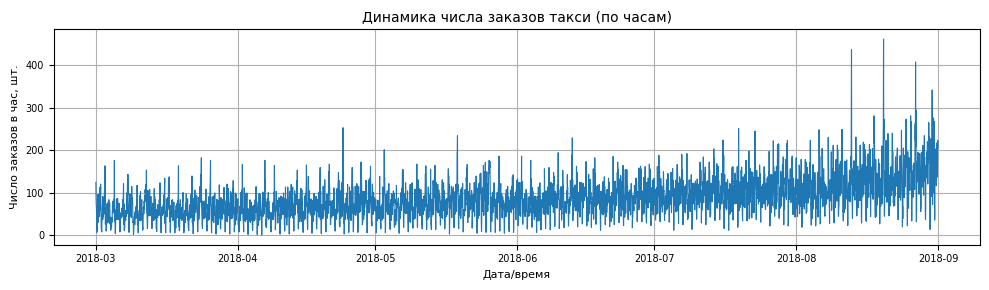

In [28]:
# Построение графика
plt.figure(figsize=(10, 3))
plt.plot(df_h.index, df_h['num_orders'], linestyle='-', linewidth=0.8)
plt.title('Динамика числа заказов такси (по часам)', fontsize=10)
plt.xlabel('Дата/время')
plt.ylabel('Число заказов в час, шт.')
plt.grid(True)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Добавление полей часа в сутках и дня недели

Добавляем новые переменные:
- номер часа в сутках (от 0 до 23);
- название дня недели (пн.-вс.);
- *сразу переводим новые переменные в тип* `Category (Ordered)` *- т.е. категориальные переменные, имеющие заданные порядки значений*.

In [29]:
# Добавим столбцы для часа и номера дня недели
df_h['hour'] = df_h.index.hour
df_h['day_of_week'] = df_h.index.weekday # 0 - Пн, 6 - Вс

# Преобразуем day_of_week в категориальный тип с заданным порядком
ordered_days = list(range(7)) # список от 0 до 6 -> Пн...Вс
df_h['day_of_week'] = pd.Categorical(df_h['day_of_week'],
                                     categories=ordered_days, ordered=True)

# Преобразуем hour в категориальный тип с заданным порядком
ordered_hours = list(range(24)) # список от 0 до 23
df_h['hour'] = pd.Categorical(df_h['hour'],
                              categories=ordered_hours, ordered=True)

In [31]:
print(f"Контроль смены типов и состава переменных:\n")
df_h.info()

Контроль смены типов и состава переменных:

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4416 entries, 2018-03-01 00:00:00 to 2018-08-31 23:00:00
Freq: h
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   num_orders   4416 non-null   int64   
 1   hour         4416 non-null   category
 2   day_of_week  4416 non-null   category
dtypes: category(2), int64(1)
memory usage: 78.7 KB


## Выделение обучающей выборки (для анализа данных)

Разделим данные на обучающую и тестовую выборки, при этом:
- согласно ТЗ размер тестовой выборки 10% от объема данных;
- важно сохранить хронологический порядок данных при этом разделении (тестовая выборка - строго в конце датасета);
- *таким образом, тестовая выборка изолируется от обучающей и используется только на этапе тестирования финальной модели*.

In [32]:
# Разделяем датасет на выборки
split_index = int((1 - TEST_SIZE) * len(df_h))
train_data = df_h[:split_index]
test_data = df_h[split_index:]

# Выводим размер выборок
print(f"Размер выборок:")
print(f"  train: {train_data.shape[0]} строк")
print(f"  test : {test_data.shape[0]} строк\n")
# Временной горизонт данных
print(f"Временной горизонт данных:")
print(f"  train: с {train_data.index.min()} до {train_data.index.max()}")
print(f"  test : с {test_data.index.min()} до {test_data.index.max()}")

Размер выборок:
  train: 3974 строк
  test : 442 строк

Временной горизонт данных:
  train: с 2018-03-01 00:00:00 до 2018-08-13 13:00:00
  test : с 2018-08-13 14:00:00 до 2018-08-31 23:00:00


# Исследовательский анализ данных

**Примечание**: далее работаем только с train-выборкой.

In [33]:
# запоминаем длину тестовой выборки
n_test = test_data.shape[0]
# фиксируем название целевой переменой
target_col = 'num_orders'

## Стационарность ряда

Исследуем исходный временной ряд на стационарность и наличие сезонности.

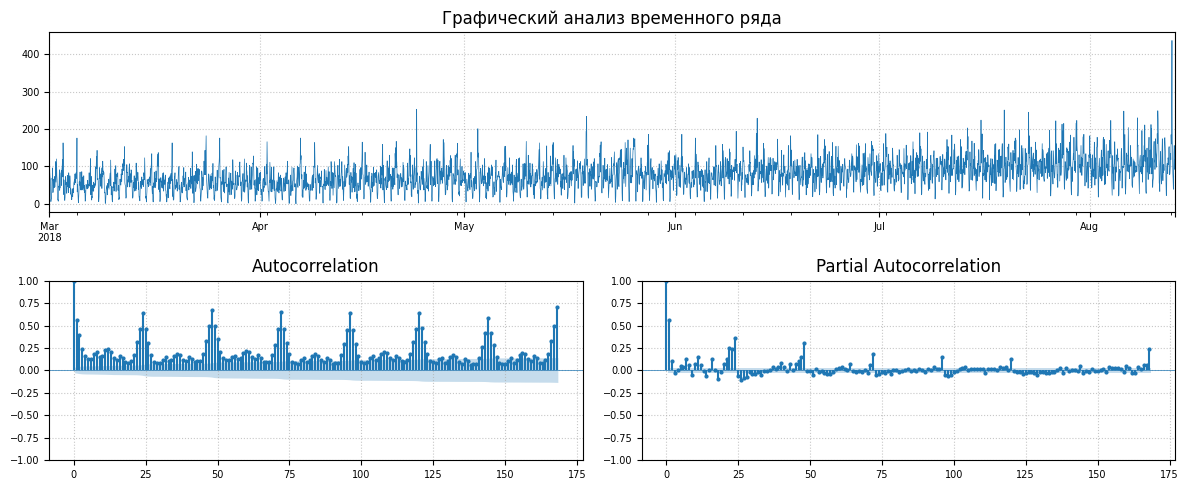


Результаты теста Дики-Фуллера для исходного ряда:
ADF Test Statistic : -4.1728
p-value : 0.0007
#Lags Used : 30
Number of Observations Used : 3943
Результат для теста с константой:
  => Ряд вероятно стационарен (отвергаем гипотезу о наличии единичного корня)


In [35]:
# строим визуализации
ts_plot(train_data['num_orders'], lags=24*7,
        figsize=(12, 5),
        linewidth_ts=0.5, linewidth_corr=0.5,
        marker_size=2,
        grid_alpha=0.7, grid_linestyle=':')

# проверяем ряд на стационарность по критерию Дики-Фулера
check_stationarity(train_data['num_orders'], title="исходного ряда")

Из графика выше видно, что:
- по тесту Дики-Фуллера: ряд вероятно стационарен;
- по графику автокорреляции: явно видна сезонность в данных; сезонность кратна ~24 часам.

Исследуем/вычислим сезонность в данных точнее.

## Сезонность ряда

Принципы анализа сезонности:
- у нас есть данные (в обучающей выборке) с 1 марта по 13 августа 2018 года;
- значит у нас нет возможности проводить анализ помесячной сезонности (нет полного года в данных, нет данных за несколько лет);
- на предварительнорм этапе быля выявлена сезонность, кратная ~24 часам (сутки);
- проведем визуализацию сезонности заказов по двум периодам: сутки (24 часа) и неделя (168 часов); 
- параметр визуализации - среднее число заказов (в разбивке на дни неделе и часы в сутках).

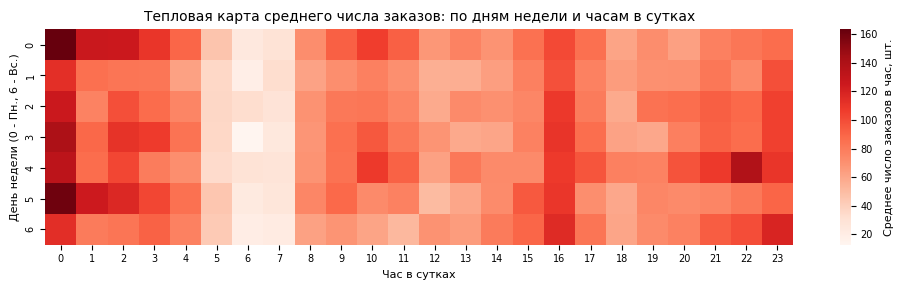

In [36]:
# Группируем данные по дню недели и часу в сутках
# Так как day_name и hour - Categorical (Ordered),
# то нужная сортировка значений - автоматом
heatmap_data = (
    train_data
    .groupby(['day_of_week', 'hour'])[target_col]
    .mean() # параметр визуализации - среднее число заказов за час
    .unstack(fill_value=0)
)

plt.figure(figsize=(10, 3))
sns.heatmap(heatmap_data, annot=False, cmap="Reds",
            cbar_kws={'label': 'Среднее число заказов в час, шт.'})
plt.title('Тепловая карта среднего числа заказов: по дням недели и часам в сутках',
          fontsize=10)
plt.xlabel('Час в сутках')
plt.ylabel('День недели (0 - Пн., 6 - Вс.)')
plt.tight_layout()
plt.show()

Из тепловой карты выше видно, что при усреднении часовых данных о заказах такси:
- *есть сезонность внутри суток*, например:
  - в период с 5:00 до 7:59 среднее число заказов в сутках минимально;
  - в период с 0:00 до 00:59 среднее число заказов близко к максимальным значениям;
  - эти факты наблюдаются практически независимо от дня недели;
- *сезонность внутри суток комбинируется с сезонностью по дням недели*, например:
  - среднее число заказов близкое к максимальным значениям наблюдается с 0:00 до 00:59 в пн. и сб., а также с 22:00 до 23:00 в пт.

Проведем декомпозицию значений временного ряда по трем периодам сезонности.

In [37]:
# Установим период
period_h = 24  # Для суточной сезонности в данных по часам

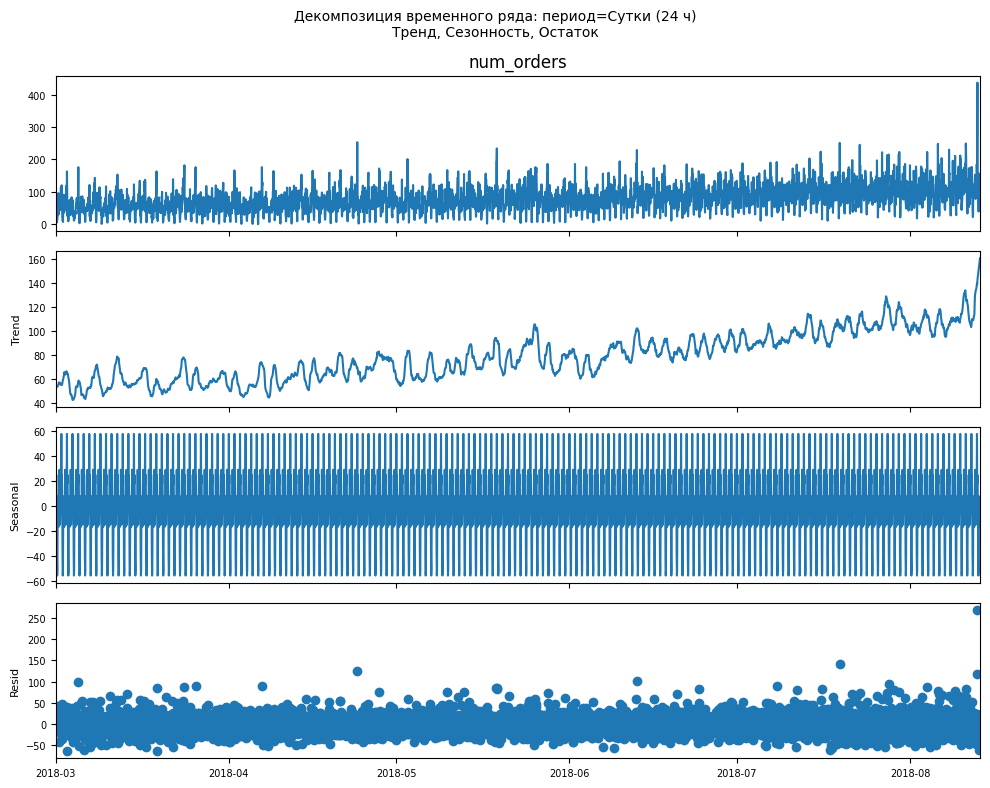


Выбранный период сезонности: Сутки (24 ч)



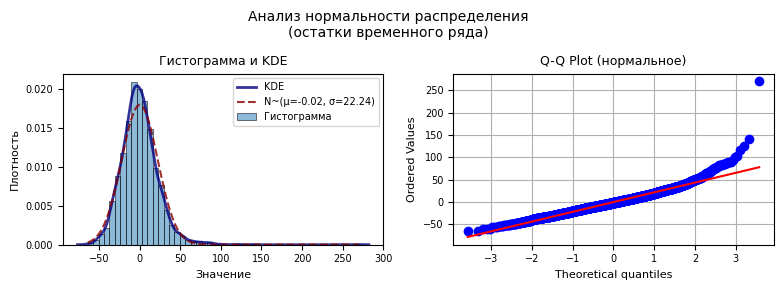

Тест Шапиро-Уилка:
  Статистика W: 0.9576
  p-value: 0.0000
  Вывод: Распределение НЕ СООТВЕТСТВУЕТ нормальному (p <= 0.05).

Интерпретация 'близости' к нормальному распределению:
  - Статистика W    = 0.9576 : ближе к 1 - ближе к нормальному распределению
  - Асимметрия (M3) = 1.0732 : |M3| < 0.5 обычно считается слабым отклонением.
  - Эксцесс (M4)    = 7.0076 : |M4| < 0.5  обычно считается слабым отклонением.
  - Визуальный осмотр графиков (гистограмма, Q-Q) - наиболее информативен.

Результаты теста Дики-Фуллера для остатков ряда:
ADF Test Statistic : -17.4249
p-value : 0.0000
#Lags Used : 31
Number of Observations Used : 3942
Результат для теста с константой:
  => Ряд вероятно стационарен (отвергаем гипотезу о наличии единичного корня)


In [38]:
# Декомпозиция и визуализация - суточная сезонность
result_h = decompose_and_analyze_ts(
    df=train_data,
    date_col='date_time',
    value_col=target_col,
    period_val=period_h,
    period_name='Сутки',
    model='additive'
)

In [39]:
# Установим период
period_w = 24 * 7  # Для недельной сезонности в данных по часам

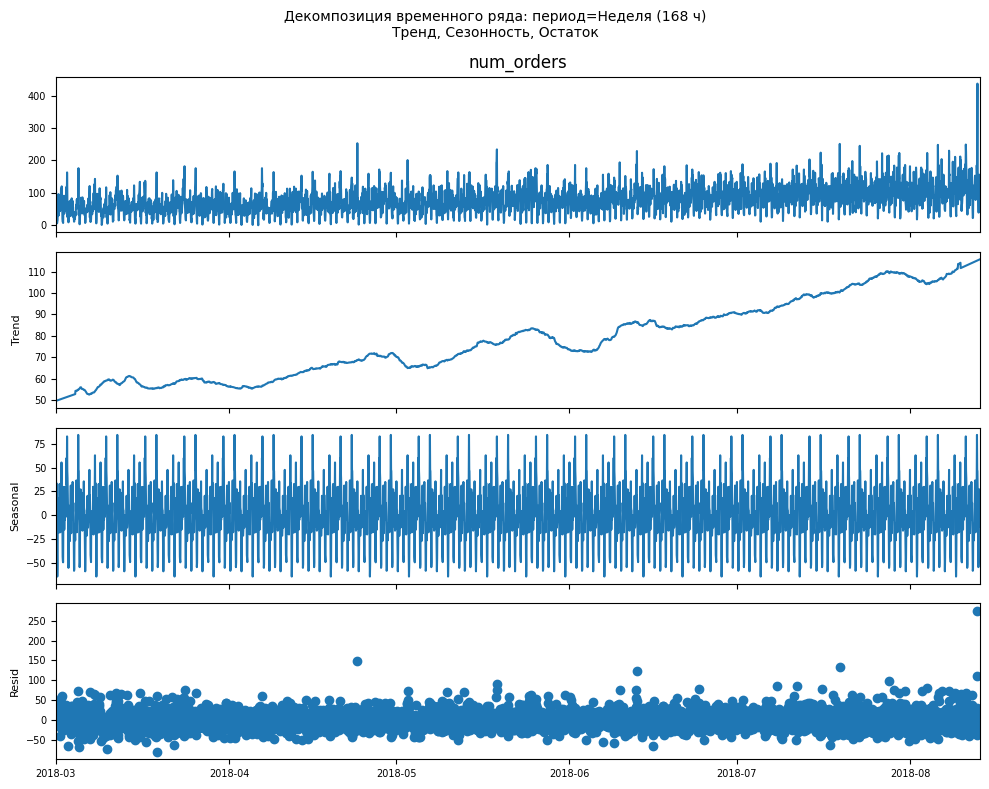


Выбранный период сезонности: Неделя (168 ч)



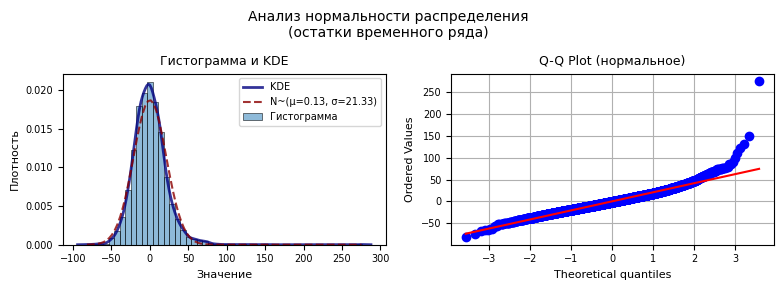

Тест Шапиро-Уилка:
  Статистика W: 0.9530
  p-value: 0.0000
  Вывод: Распределение НЕ СООТВЕТСТВУЕТ нормальному (p <= 0.05).

Интерпретация 'близости' к нормальному распределению:
  - Статистика W    = 0.9530 : ближе к 1 - ближе к нормальному распределению
  - Асимметрия (M3) = 1.1563 : |M3| < 0.5 обычно считается слабым отклонением.
  - Эксцесс (M4)    = 8.9294 : |M4| < 0.5  обычно считается слабым отклонением.
  - Визуальный осмотр графиков (гистограмма, Q-Q) - наиболее информативен.

Результаты теста Дики-Фуллера для остатков ряда:
ADF Test Statistic : -11.3225
p-value : 0.0000
#Lags Used : 31
Number of Observations Used : 3942
Результат для теста с константой:
  => Ряд вероятно стационарен (отвергаем гипотезу о наличии единичного корня)


In [40]:
# Декомпозиция и визуализация - недельная сезонность
result_h = decompose_and_analyze_ts(
    df=train_data,
    date_col='date_time',
    value_col=target_col,
    period_val=period_w,
    period_name='Неделя',
    model='additive'
)

In [43]:
# Установим период
period_m = 24 * 30 # Для месячной сезонности в данных по часам

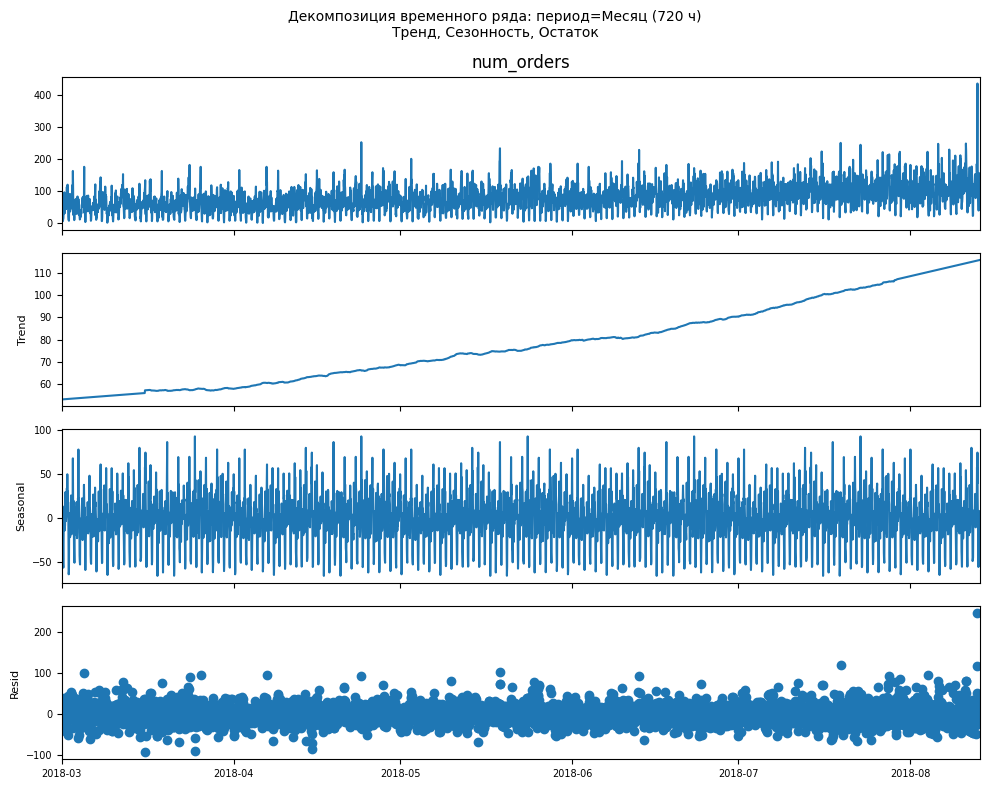


Выбранный период сезонности: Месяц (720 ч)



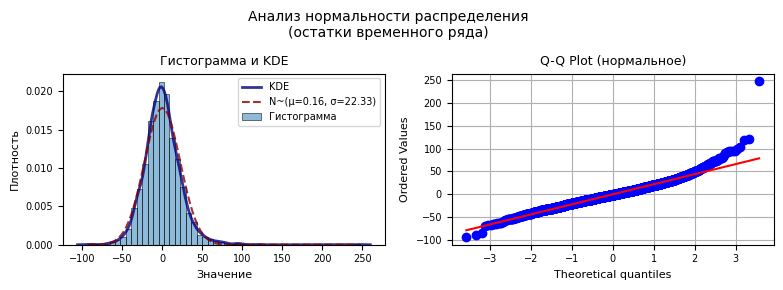

Тест Шапиро-Уилка:
  Статистика W: 0.9670
  p-value: 0.0000
  Вывод: Распределение НЕ СООТВЕТСТВУЕТ нормальному (p <= 0.05).

Интерпретация 'близости' к нормальному распределению:
  - Статистика W    = 0.9670 : ближе к 1 - ближе к нормальному распределению
  - Асимметрия (M3) = 0.7873 : |M3| < 0.5 обычно считается слабым отклонением.
  - Эксцесс (M4)    = 5.2051 : |M4| < 0.5  обычно считается слабым отклонением.
  - Визуальный осмотр графиков (гистограмма, Q-Q) - наиболее информативен.

Результаты теста Дики-Фуллера для остатков ряда:
ADF Test Statistic : -13.4510
p-value : 0.0000
#Lags Used : 31
Number of Observations Used : 3942
Результат для теста с константой:
  => Ряд вероятно стационарен (отвергаем гипотезу о наличии единичного корня)


In [44]:
# Декомпозиция и визуализация - недельная сезонность
result_h = decompose_and_analyze_ts(
    df=train_data,
    date_col='date_time',
    value_col=target_col,
    period_val=period_m,
    period_name='Месяц',
    model='additive'
)

## Выводы - анализ данных

Поскольку у нас есть данные только за март-август 2018 года, то выделять ежемесячную сезонность в данных не имеет смысла (т.к. у нас нет данных за несколько лет и мы не можем сравнивать соотвествующие месяцы в разных календарных годах).

Стационарность, автокорреляции:
- по тесту Дики-Фуллера: ряд вероятно стационарен;
- по графику автокорреляции: явно видна сезонность в данных; сезонность кратна 24 часам.

Из графиков виузализации сезонности видно, что:
- *есть сезонность внутри суток*, например:
  - в период с 5:00 до 7:59 среднее число заказов в сутках минимально;
  - в период с 0:00 до 00:59 среднее число заказов близко к максимальным значениям;
  - эти факты наблюдаются практически независимо от дня недели;
- *сезонность внутри суток комбинируется с сезонностью по дням недели*, например:
  - среднее число заказов близкое к максимальным значениям наблюдается с 0:00 до 00:59 в пн. и сб., а также с 22:00 до 23:00 в пт.
- при выделении суточной сезонности в часовых данных:
  - распределение остатков: в целом близко к нормальному, есть некоторое число выбросов в правом хвосте распределения;
  - выделенный тренд: имеет внутри себя явно видимую неучтенную сезонность;
  - ряд остатков: стационарен;
- при выделении недельной сезонности часовых в данных:
  - распределение остатков: в целом близко к нормальному, есть некоторое число выбросов в правом хвосте распределения;
  - выделенный тренд: не имеет внутри себя явной видимой неучтенной сезонности (хотя она там возможно и есть на помесячных данных);
  - ряд остатков: стационарен.

***Выводы***:
- исходный ряд стационарен (по тесту Дики-Фуллера); *можно использовать исходный ряд для построение моледей ML*;
- в исходном ряду присутствует сезонность; сезонность кратна 24 часам; при построении прогнозов необходимо учитывать наличие *ежесуточной + еженедельной сезонности в часовых данных по заказам такси*.

***Дополнительные соображения - трендовая компонента***:
- из графиков декомпозиции видно, что с марта по август 2018 года наблюдается умеренный восходящий тренд (рост числа заказов); это может быть важно для понимания поведения моделей на тестовом периоде, который является «самым свежим» по времени;
- поэтому возможная разница между метриками при обучении, валидации и тесте, не обязательно будет объясняться только переобучением модели.


# Прогнозирование - без машинного обучения

## 'Наивные' прогнозы

Проведем т.н. "наивное" прогнозирование значений временного ряда таким способом:
- число заказов такси на следующий час прогнозируется как соотвествующее значение на несколько часов тому назад;
- период временного "сдвига" при прогнозе (фактически период сезонности числа заказов такси) подбирается в цикле;
- метрика для выбора оптимального периода сезонности/сдвига: RMSE на обучающей выборке.

In [45]:
# Проведем поиск оптимального периода сезонности для 'наивного' прогноза
results_1 = {}

for per in range(1, 24 * 7 * 8 + 1): # период от 1 часа до 8 недель
    rmse_result = calculate_naive_rmse_on_train(
        train_data[target_col],
        per
    )
    results_1[per] = rmse_result

df_results_1 = pd.DataFrame(list(results_1.items()), columns=['period', 'rmse'])

Минимальный RMSE на обучающей выборке: 25.93
при периоде сезонности: 168 час.


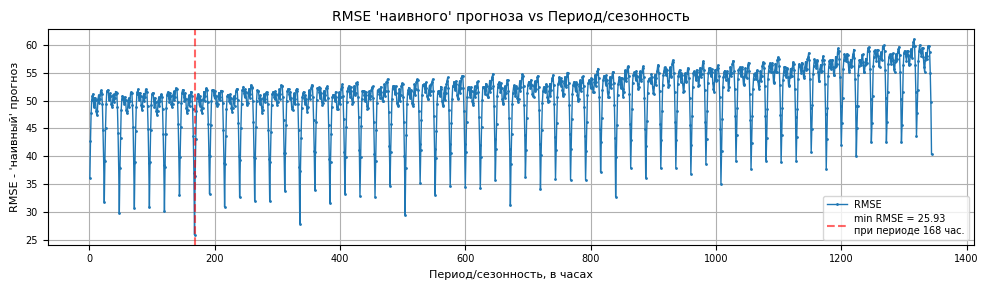

Периоды сезонности с минимальными значениями RMSE:


,period,rmse
167,168,25.930
335,336,27.940
503,504,29.490
47,48,29.880
119,120,30.270
71,72,30.810
95,96,30.900
215,216,30.940
671,672,31.280
383,384,31.640


Минимальный RMSE на обучающей выборке: 25.93
при периоде сезонности: 168 час.


In [46]:
# Найти индекс строки с минимальным значением RMSE
min_rmse_idx = df_results_1['rmse'].idxmin()
# Получить соответствующий период и значение RMSE
min_period = df_results_1.loc[min_rmse_idx, 'period']
min_rmse_value = df_results_1.loc[min_rmse_idx, 'rmse']

print(f"Минимальный RMSE на обучающей выборке: {min_rmse_value:.2f}"
      f"\nпри периоде сезонности: {min_period} час.")

# Построение графика
plt.figure(figsize=(10, 3))
plt.plot(df_results_1['period'], df_results_1['rmse'],
         marker='o', markersize=1, linestyle='-', linewidth=1, label='RMSE')
plt.axvline(x=min_period, color='r',
            linestyle='--', linewidth=1.5,
            label=f"min RMSE = {min_rmse_value:.2f}\nпри периоде {min_period} час.",
            alpha=0.6)
plt.title("RMSE 'наивного' прогноза vs Период/сезонность", fontsize=10)
plt.xlabel("Период/сезонность, в часах")
plt.ylabel("RMSE - 'наивный' прогноз")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

print("Периоды сезонности с минимальными значениями RMSE:")
display(df_results_1.nsmallest(15, 'rmse'))

print(f"Минимальный RMSE на обучающей выборке: {min_rmse_value:.2f}"
      f"\nпри периоде сезонности: {min_period} час.")

Построим визуализацию 'наивного' прогноза (на последних точках обучающей выборки).

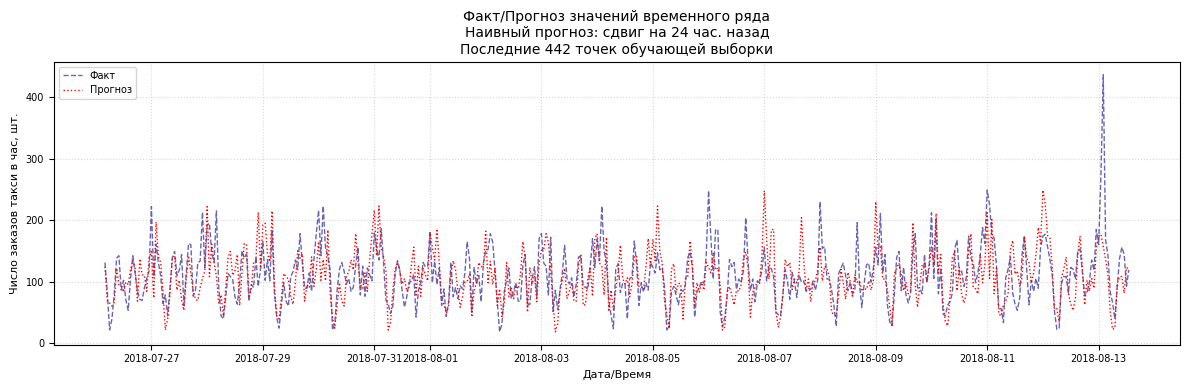

RMSE Наивный прогноз: сдвиг на 24 час. назад:
  Вся обучающая выборка                : 31.77
  Последние 442 точек обучающей выборки: 40.88


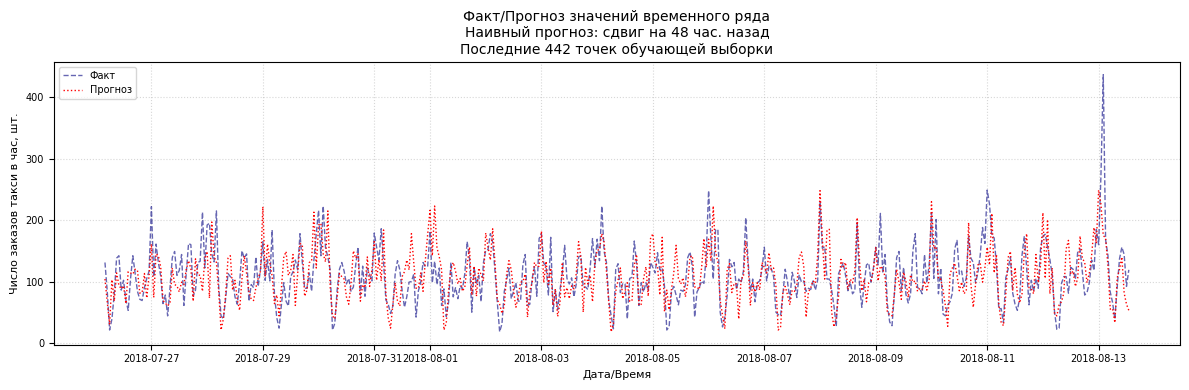

RMSE Наивный прогноз: сдвиг на 48 час. назад:
  Вся обучающая выборка                : 29.80
  Последние 442 точек обучающей выборки: 38.48


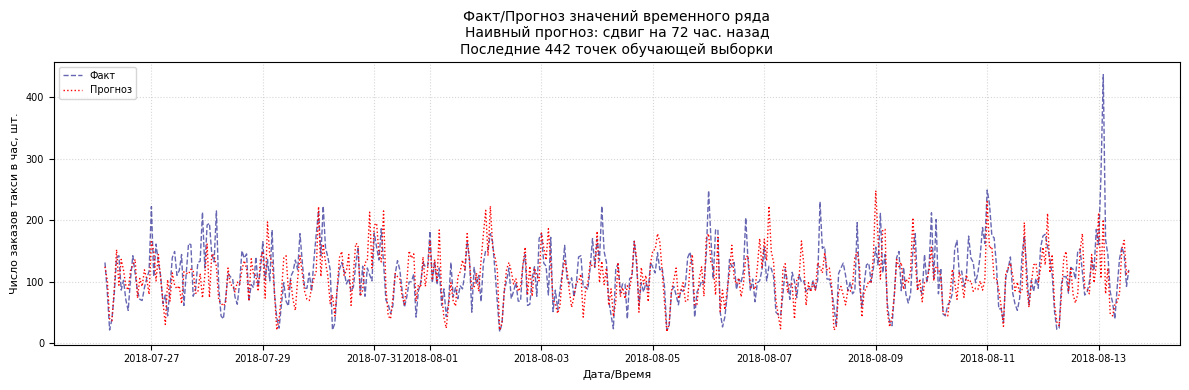

RMSE Наивный прогноз: сдвиг на 72 час. назад:
  Вся обучающая выборка                : 30.76
  Последние 442 точек обучающей выборки: 38.37


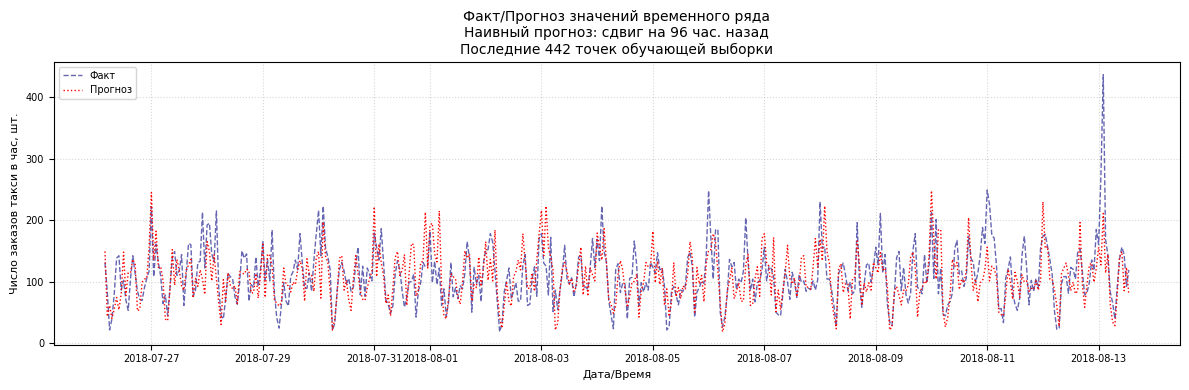

RMSE Наивный прогноз: сдвиг на 96 час. назад:
  Вся обучающая выборка                : 30.84
  Последние 442 точек обучающей выборки: 37.98


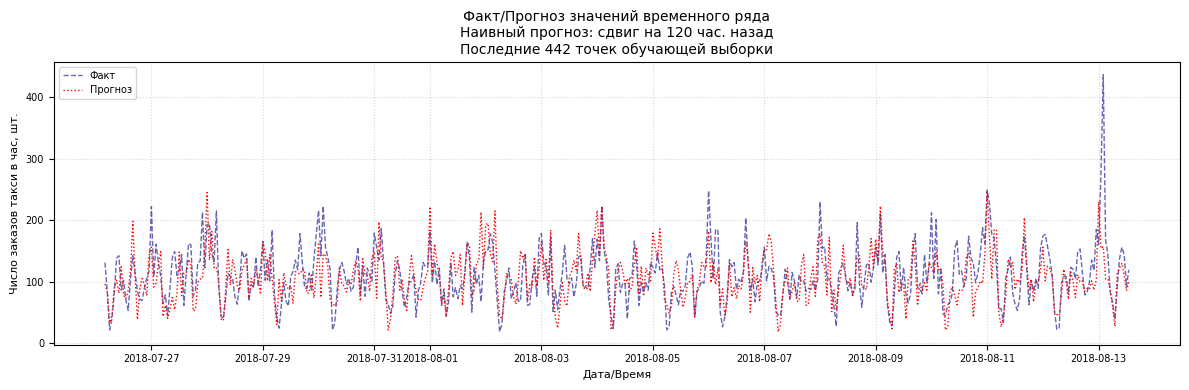

RMSE Наивный прогноз: сдвиг на 120 час. назад:
  Вся обучающая выборка                : 30.07
  Последние 442 точек обучающей выборки: 38.43


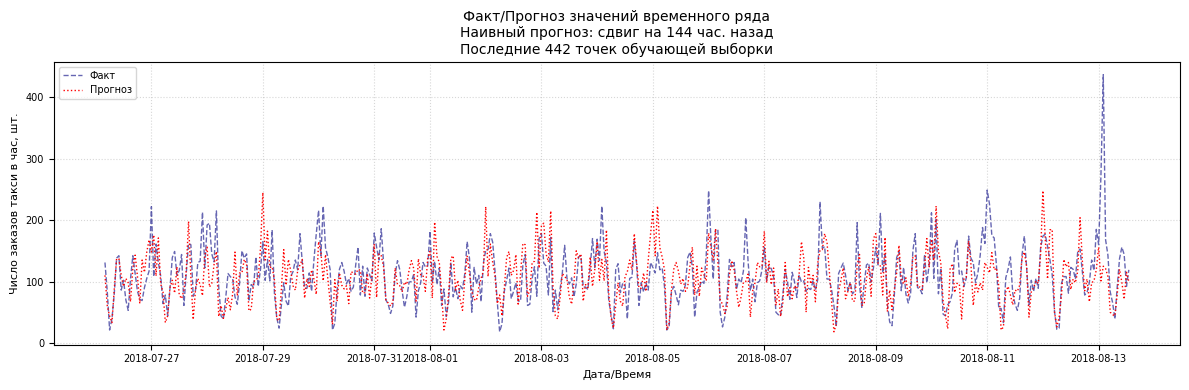

RMSE Наивный прогноз: сдвиг на 144 час. назад:
  Вся обучающая выборка                : 32.83
  Последние 442 точек обучающей выборки: 41.34


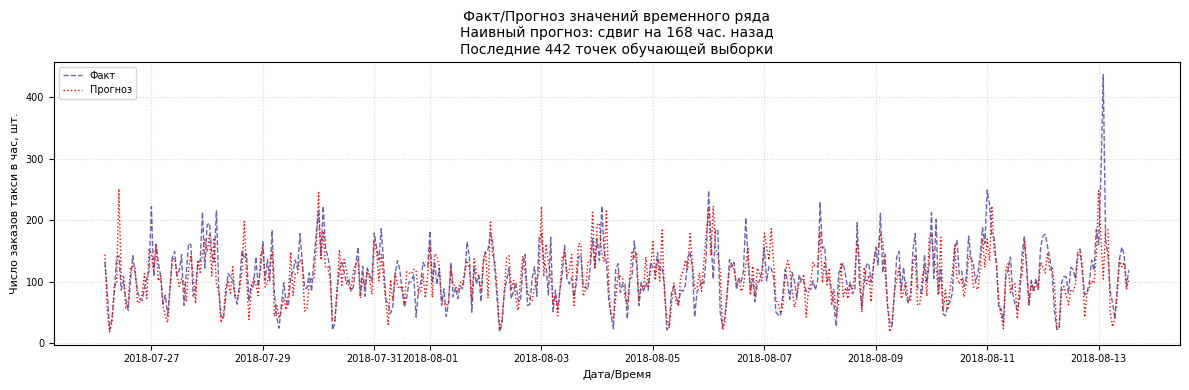

RMSE Наивный прогноз: сдвиг на 168 час. назад:
  Вся обучающая выборка                : 25.83
  Последние 442 точек обучающей выборки: 33.99


In [47]:
# перебор в цикле по сезонности кратной суткам от 1 суток до 1 недели
for lag_0 in range(24, 24 * 7 + 1, 24):

    # Наивный прогноз, сдвиг lag_0 часов назад
    naive_forecast = train_data[target_col].shift(lag_0)

    # Выбираем последние точки train-выборки для визуализации
    last_ind = train_data.index[-n_test:]
    fact_values = train_data.loc[last_ind, target_col]
    forecast_values = naive_forecast.loc[last_ind]

    # Построение графика
    plot_ts_forecast_graph(
        fact_values, forecast_values,
        figsize=(12, 4),
        name_model=f"Факт/Прогноз значений временного ряда\nНаивный прогноз: сдвиг на {lag_0} час. назад\nПоследние {n_test} точек обучающей выборки",
        name_x='Дата/Время',
        name_y='Число заказов такси в час, шт.'
    )

    # Расчет RMSE
    rmse_all_train = np.sqrt(
        ((train_data[target_col] - naive_forecast).dropna() ** 2).mean()
    )
    rmse_last_train = np.sqrt(((fact_values - forecast_values) ** 2).mean())
    print(f"RMSE Наивный прогноз: сдвиг на {lag_0} час. назад:")
    print(f"  Вся обучающая выборка                : {rmse_all_train:.2f}")
    print(f"  Последние {n_test} точек обучающей выборки: {rmse_last_train:.2f}")

In [48]:
# Переменная для хранения нужных результатов моделирования
models_results = {}

model_name = 'Naive_Seasonal_Weekly'

models_results[model_name] = {}
models_results[model_name]['best_model'] = 'Прогноз на неделю назад'
models_results[model_name]['train_all_rmse'] = rmse_all_train
models_results[model_name]['train_last_rmse'] = rmse_last_train


## Выводы - 'наивные' прогнозы

Проведено т.н. "наивное" прогнозирование значений временного ряда таким способом:
- число заказов такси на следующий час прогнозируется как соотвествующее значение на несколько часов тому назад;
- период временного "сдвига" при прогнозе:
  - начинается с 24 часов, принимается кратным 24 часам (сутки), максимум - 168 часов (неделя);
- метрика для выбора оптимального периода сезонности/сдвига: RMSE на обучающей выборке.

Итоги:
- как видно из графиков выше:
  - наилучший результат показывает прогноз со сдвигом на неделю (168 часов назад);
  - в целом наивный прогноз исторически неплохо попадает в фактические значения, однако ближе к концу обучающей выборки плохо улавливает пиковые выбросы числа заказов (выбросы вверх);
- лучшая метрика RMSE получена на варианте прогноза значением на неделю назад (-168 часов от прогнозного часа);
- <u>целевая метрика удовлетворяет условию задания</u>:
  - по всей обучающей выборке: `RMSE = 25.83 < 48`;
  - по последним точкам обучающей выборки (размер окна прогнорза = размеру тестовой выборки): `RMSE = 33.99 < 48`.

**Далее проведем построение иных моделей ML и попытаемся улучшить качество 'наивного' прогноза**.

## SARIMAX

Обучение модели ARIMA (AutoRegressive Integrated Moving Average) - это процесс построения статистической модели для анализа и прогнозирования временных рядов. Модель ARIMA учитывает четыре ключевых компонента:
- сезонность (S);
- авторегрессию (AR);
- интегрирование (I);
- скользящее среднее (MA).

Ключевые условия применения метода:
- временной ряд представлен в виде упорядоченного по времени набора значений, шаг даты/времени - фиксирован;
- временной ряд должен быть стационарным (статистические свойства, такие как среднее и дисперсия, не изменяются со временем); если ряд нестационарен, его нужно продифференцировать (например, вычислить разности между последовательными значениями или сезонными значениями).


### Шаг 1: начальный анализ

Исследуем исходный временной ряд на стационарность.

In [49]:
# Делаем копию данных для работы
ar_data = train_data[target_col].copy().to_frame(name=target_col)
ar_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3974 entries, 2018-03-01 00:00:00 to 2018-08-13 13:00:00
Freq: h
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   num_orders  3974 non-null   int64
dtypes: int64(1)
memory usage: 191.1 KB


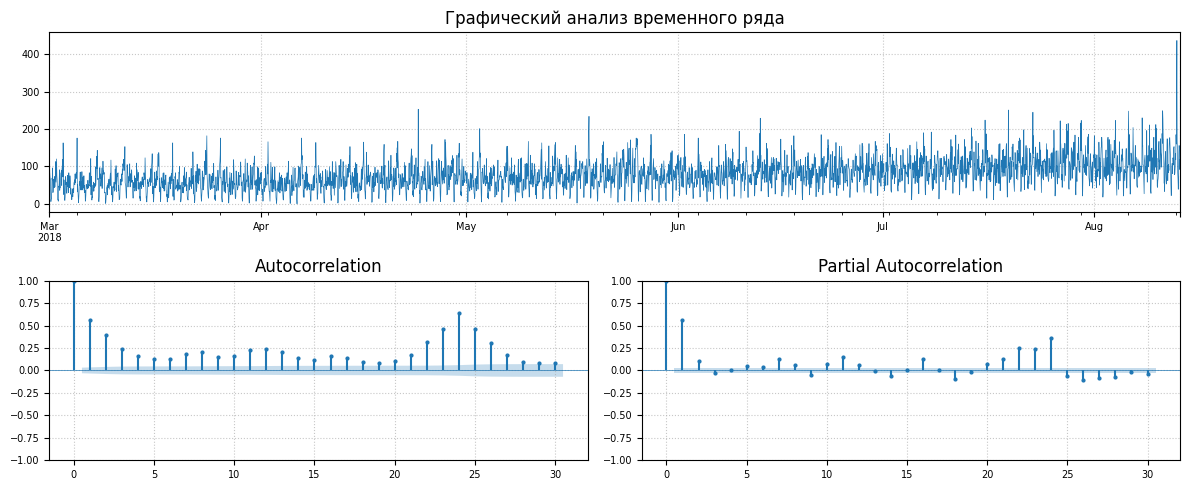


Результаты теста Дики-Фуллера для исходного ряда:
ADF Test Statistic : -4.1728
p-value : 0.0007
#Lags Used : 30
Number of Observations Used : 3943
Результат для теста с константой:
  => Ряд вероятно стационарен (отвергаем гипотезу о наличии единичного корня)


In [50]:
# строим визуализации
ts_plot(ar_data[target_col], lags=30,
        figsize=(12, 5),
        linewidth_ts=0.5, linewidth_corr=0.5,
        marker_size=2,
        grid_alpha=0.7, grid_linestyle=':')

# проверяем ряд на стационарность по критерию Дики-Фулера
check_stationarity(ar_data[target_col], title="исходного ряда")

**Итоги - Шаг 1**:
- по тесту Дики-Фуллера: ряд вероятно стационарен;
- по графику автокорреляции:
  - явно видна сезонность в данных;
  - сезонность кратна 24 часам.

***Для начала возьмем сезонные разности исходного ряда***.

### Шаг 2: сезонные разности

In [51]:
# Берем сезонную разность ряда
ar_data['diff_24'] = ar_data[target_col].diff(periods=24)

In [52]:
# проверяем ряд на стационарность по критерию Дики-Фулера
check_stationarity(ar_data['diff_24'], title="ряда сезонных разностей")


Результаты теста Дики-Фуллера для ряда сезонных разностей:
ADF Test Statistic : -15.1161
p-value : 0.0000
#Lags Used : 31
Number of Observations Used : 3918
Результат для теста с константой:
  => Ряд вероятно стационарен (отвергаем гипотезу о наличии единичного корня)


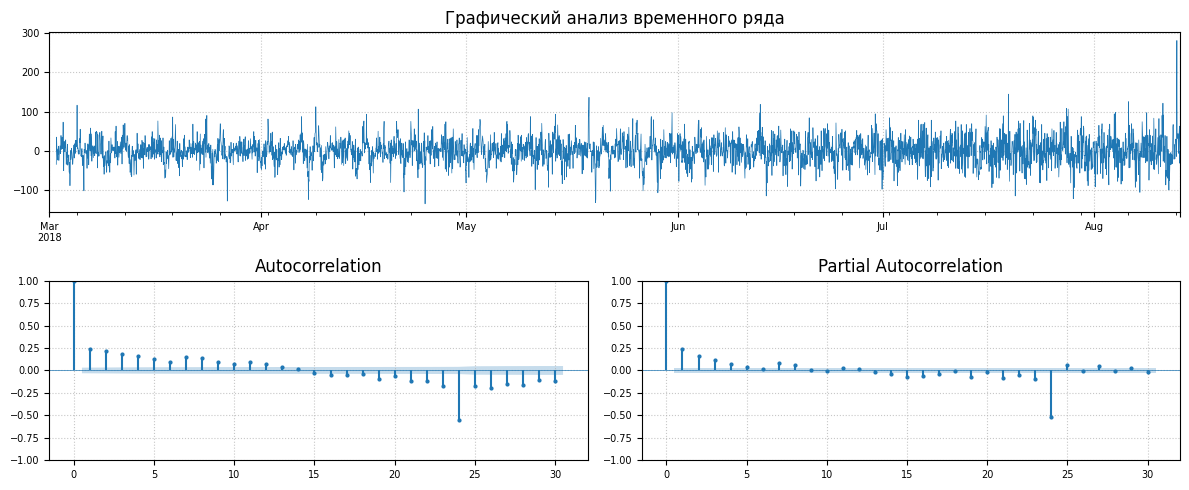

In [53]:
# строим визуализации
ts_plot(ar_data['diff_24'], lags=30,
        figsize=(12, 5),
        linewidth_ts=0.5, linewidth_corr=0.5,
        marker_size=2,
        grid_alpha=0.7, grid_linestyle=':')

**Итоги - Шаг 2**:
- по тесту Дики-Фуллера: ряд вероятно стационарен;
- по графику автокорреляции:
  - явно видна еще оставшаяся сезонность в данных на 24 часах;
  - далее автокорреляции осциллируют затухая.

***Теперь возьмем простые разности преобразованного ряда***.

### Шаг 3: дополнительно - простые разности

In [54]:
# Берем простую разность преобразованного ряда
ar_data['diff_24_and_then_1'] = ar_data['diff_24'].diff(periods=1)

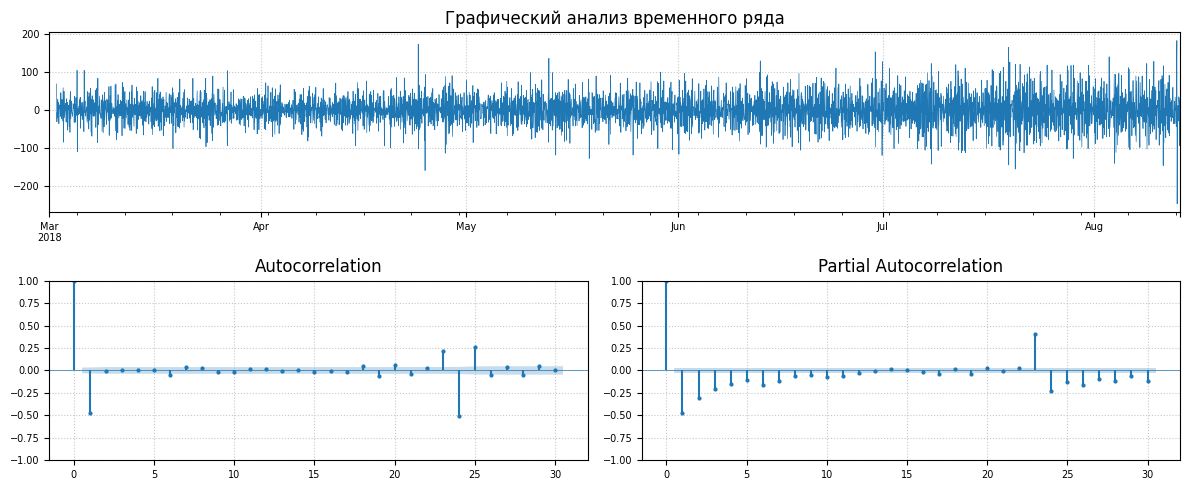

In [55]:
# строим визуализации
ts_plot(ar_data['diff_24_and_then_1'], lags=30,
        figsize=(12, 5),
        linewidth_ts=0.5, linewidth_corr=0.5,
        marker_size=2,
        grid_alpha=0.7, grid_linestyle=':')

**Итоги - Шаг 3**:
- по тесту Дики-Фуллера: ряд вероятно стационарен;
- по графикам автокорреляции видно что есть частично неустраненная сезонность;
- <u>однако примем за основу полученные преобразования и построим модели `SARIMA`</u>.

***Выводы для параметров SARIMA***:
- d (нестационарность): уже подтверждено d=1 (применена diff(periods=1)).
- D (сезонная нестационарность): уже подтверждено D=1 (применена diff(periods=24)).
- m (период сезонности): m=24.
- p (нестационарный AR): PACF показывает затухание, что указывает на p >= 1. Возможно, p = 1 или p = 2. ACF не противоречит этому, так как MA(1) + AR(p) может давать сложную картину. Стоит рассмотреть p = 0, 1, 2.
- q (нестационарный MA): ACF показывает резкий пик на лаге 1, что очень сильно указывает на q = 1 . Это основной признак.
- P (сезонный AR): PACF показывает пик на 24, что указывает на P = 1. Стоит рассмотреть P = 0, 1.
- Q (сезонный MA): ACF показывает пики на 23, 24, 25, особенно центральный пик на 24, что указывает на Q = 1. Стоит рассмотреть Q = 0, 1.

***Вывод по преобразованию данных***:
- `diff_24_and_then_1` - стационарен.
- Модель `SARIMA` должна быть обучена на исходном ряде с d=1, D=1:
  - т.е. `SARIMA(order=(p,1,q), seasonal_order=(P,1,Q,24))`;
  - прочие возможные параметры:
    - p = 0, 1, 2;
    - q = 1;
    - P = 0, 1;
    - Q = 1. 

### Шаг 4: обучение SARIMA

In [ ]:
# Используем диапазоны с учетом анализа выше
param_ranges = {
    'p': (0, 2),  # p = 0, 1, 2 (PACF указывает на AR)
    'q': (1, 1),  # q = 1 (ACF указывает на MA(1))
    'P': (0, 1),  # P = 0, 1 (PACF указывает на SAR)
    'Q': (1, 1),  # Q = 1 (ACF указывает на SMA)
}
d_fixed = 1
D_fixed = 1
m_fixed = 24

# Запуск поиска перебором по сетке
(best_manual_model, best_manual_order,
 best_manual_seasonal_order, best_manual_aic,
 best_manual_bic, best_rmse_full, best_rmse_last,
 search_results_df
) = grid_search_sarimax_with_rmse(
    train_data, n_test, target_col,
    d_fixed, D_fixed, m_fixed,
    param_ranges, maxiter=100
)

if best_manual_model:
    print("\nКраткая информация о лучшей ручной модели:")
    print(best_manual_model.summary())
else:
    print("\nНе удалось найти подходящую модель в ходе перебора.")

# Создание DataFrame с результатами для анализа
search_results_df = pd.DataFrame(search_results_df)
# Сортировка по AIC
sorted_results_by_aic = search_results_df.sort_values(by='aic').head(10) # Топ 10 по AIC
print("\nТоп моделей по AIC (с RMSE)")
display(sorted_results_by_aic[['order', 'seasonal_order',
                               'aic', 'bic',
                               'rmse_full_train', 'rmse_last_train']])

Перебираем 6 комбинаций параметров... Печать следующей строки, только если модель лучше предыдущей по AIC!
Найдена лучшая модель по AIC: (0, 1, 1)(0, 1, 1, 24), AIC: 35727.41, BIC: 35746.26, RMSE_full: 22.39, RMSE_last: 29.76
Найдена лучшая модель по AIC: (0, 1, 1)(1, 1, 1, 24), AIC: 35698.42, BIC: 35723.54, RMSE_full: 22.30, RMSE_last: 29.53
Найдена лучшая модель по AIC: (1, 1, 1)(1, 1, 1, 24), AIC: 35679.82, BIC: 35711.22, RMSE_full: 22.25, RMSE_last: 29.25
Найдена лучшая модель по AIC: (2, 1, 1)(1, 1, 1, 24), AIC: 35665.07, BIC: 35702.76, RMSE_full: 22.19, RMSE_last: 29.17

--- Поиск завершён ---
Лучшая модель (по AIC): (2, 1, 1)(1, 1, 1, 24)
Лучший AIC: 35665.07
Лучший BIC: 35702.76
RMSE на всей train: 22.19
RMSE на последних 442 точках train: 29.17

Краткая информация о лучшей ручной модели:
                                     SARIMAX Results                                      
Dep. Variable:                         num_orders   No. Observations:                 3974
Model:    

,order,seasonal_order,aic,bic,rmse_full_train,rmse_last_train
5,"(2, 1, 1)","(1, 1, 1, 24)","35,665.072","35,702.759",22.194,29.165
3,"(1, 1, 1)","(1, 1, 1, 24)","35,679.816","35,711.222",22.249,29.252
4,"(2, 1, 1)","(0, 1, 1, 24)","35,690.017","35,721.423",22.264,29.394
1,"(0, 1, 1)","(1, 1, 1, 24)","35,698.415","35,723.540",22.301,29.532
2,"(1, 1, 1)","(0, 1, 1, 24)","35,711.685","35,736.810",22.339,29.512
0,"(0, 1, 1)","(0, 1, 1, 24)","35,727.414","35,746.258",22.388,29.761


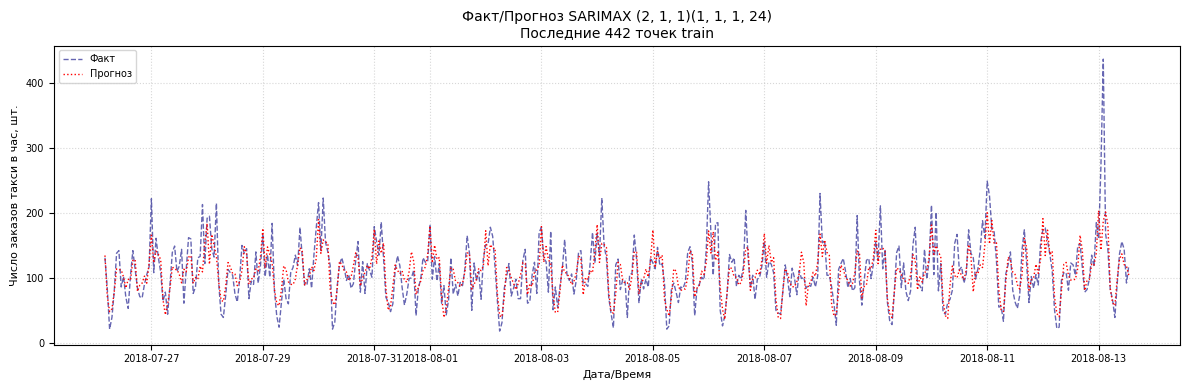


Результаты SARIMAX (2, 1, 1)(1, 1, 1, 24)
RMSE (вся train): 22.19
RMSE (последние 442 train): 29.17


In [57]:
# 1. Подготовка данных для прогноза и визуализации
last_ind = train_data.index[-n_test:]
fact_values_train_part = train_data.loc[last_ind, target_col]
# Берем подогнанные значения (fitted values) для последнего участка train
forecast_values_sarimax = best_manual_model.fittedvalues.loc[last_ind]

# 2. Визуализация
plot_ts_forecast_graph(
    fact_values_train_part, forecast_values_sarimax,
    figsize=(12, 4),
    name_model=f"Факт/Прогноз SARIMAX {best_manual_order}{best_manual_seasonal_order}\nПоследние {n_test} точек train",
    name_x='Дата/Время',
    name_y='Число заказов такси в час, шт.'
)

# 3. Расчет RMSE
# Вся train
all_train_actual = train_data[target_col]
all_train_fitted = best_manual_model.fittedvalues
rmse_all_train_sarimax = rmse_rounded(all_train_actual, all_train_fitted)

# Последние n_test точек train
rmse_last_train_sarimax = rmse_rounded(fact_values_train_part, forecast_values_sarimax)

# 4. Сохранение результатов
model_name_sarimax = 'SARIMAX_211_111_24'
models_results[model_name_sarimax] = {
    'best_model': best_manual_model,
    'train_all_rmse': rmse_all_train_sarimax,
    'train_last_rmse': rmse_last_train_sarimax
}

print(f"\nРезультаты SARIMAX {best_manual_order}{best_manual_seasonal_order}")
print(f"RMSE (вся train): {rmse_all_train_sarimax:.2f}")
print(f"RMSE (последние {n_test} train): {rmse_last_train_sarimax:.2f}")

## Выводы - SARIMAX

Модель `SARIMA (2, 1, 1)(1, 1, 1, 24)` - лучшая по всем метрикам.

1. Структура модели:
- `SARIMAX(2, 1, 1)x(1, 1, 1, 24)`
- Несезонная часть: `(2, 1, 1)`
  - p=2: Авторегрессионная компонента второго порядка. Текущее значение зависит от двух предыдущих значений ряда (после несезонной разности).
  - d=1: Одна несезонная разность была применена.
  - q=1: Скользящее среднее первого порядка. Ошибка прогноза на один шаг зависит от одной предыдущей ошибки.
- Сезонная часть: `(1, 1, 1, 24)`
  - P=1: Сезонная авторегрессия первого порядка. Текущее значение (после разностей) зависит от значения 24 периода назад (после разностей).
  - D=1: Одна сезонная разность применена для устранения сезонной компоненты.
  - Q=1: Сезонное скользящее среднее первого порядка. Сезонная ошибка прогноза зависит от одной предыдущей сезонной ошибки (с лагом 24).
  - m=24: Период сезонности (24 часа).

2. Параметры модели:
  - ar.L1 (0.1591): Коэффициент при первом лаге в несезонной AR(2) части. Положительный и статистически значим (p-value ~ 0.000).
  - ar.L2 (0.1063): Коэффициент при втором лаге в несезонной AR(2) части. Положительный и статистически значим (p-value ~ 0.000).
  - ma.L1 (-0.9754): Коэффициент при несезонной MA(1) части. Отрицательный, близкий к -1, и статистически значим (p-value ~ 0.000). Это указывает на сильное влияние предыдущей ошибки.
  - ar.S.L24 (-0.0980): Коэффициент при сезонной AR(1) части. Отрицательный, относительно мал по модулю, но статистически значим (p-value ~ 0.000). Это означает, что текущее значение (после разностей) слегка отрицательно коррелировано со значением 24 часа назад (после разностей).
  - ma.S.L24 (-0.8945): Коэффициент при сезонной MA(1) части. Отрицательный, близкий к -1, и статистически значим (p-value ~ 0.000). Это указывает на сильное влияние ошибки прогноза 24 часа назад.
  - sigma2 (482.33): Оценка дисперсии остатков. Указывает на уровень "шума" в модели.

3. Диагностика остатков:
  - Ljung-Box Test (Prob(Q)): Prob(Q): 0.63. P-значение 0.63, что значительно выше 0.05. ***Он говорит о том, что остатки не имеют статистически значимой автокорреляции на первом лаге (обычно L1)***. Это указывает на то, что модель хорошо улавливает динамику ряда.
  - Jarque-Bera Test (Prob(JB)): Prob(JB): 0.00. P-значение 0.00, что ниже 0.05. ***Это означает, что распределение остатков статистически значимо отличается от нормального***. Это видно и по высокой асимметрии (Skew: 1.04) и высокому эксцессу (Kurtosis: 9.15). Модель SARIMA не требует строго нормальных остатков, но это может повлиять на доверительные интервалы прогноза.
  - Heteroskedasticity Test (Prob(H)): Prob(H): 0.00. P-значение 0.00, что ниже 0.05. Это означает, что дисперсия остатков не постоянна (гетероскедастична). Это также может повлиять на надежность стандартных ошибок параметров и доверительных интервалов.

4. Точность прогноза:
- в целом SARIMAX исторически неплохо попадает в фактические значения, однако иногда плохоо улавливает пиковые выбросы числа заказов (выбросы вверх);
- <u>целевая метрика удовлетворяет условию задания</u>:
  - по всей обучающей выборке: `RMSE = 22.19 < 48`;
  - по последним точкам обучающей выборки (размер окна прогнорза = размеру тестовой выборки): `RMSE = 29.17 < 48`.


***Выводы по модели***:
- Модель `SARIMAX(2, 1, 1)x(1, 1, 1, 24)` показала лучший AIC среди рассмотренных. Она учитывает сложную структуру данных:
  - Тренд (d=1) и сезонную интеграцию (D=1).
  - Несезонную динамику через AR(2) и MA(1).
  - Сезонную динамику через SAR(1) и SMA(1).
- Диагностика остатков показывает, что автокорреляция в остатках устранена (Ljung-Box Test), что говорит о хорошей адаптации модели к данным. Однако остатки не нормальны и гетероскедастичны. Это не делает модель плохой для прогнозирования, но указывает на то, что доверительные интервалы и статистические тесты для параметров могут быть менее надежными.
- С точки зрения RMSE, модель показывает умеренные ошибки как на всем обучающем наборе, так и на его последнем участке, аналогичном по длине тестовому. Это свидетельствует о способности модели достаточно хорошо воспроизводить паттерны ряда.

**Далее проведем построение иных моделей ML и попытаемся улучшить качество прогноза**.

# Подготовка данных для ML

## Ввод новых переменных

На основании анализа сезонности в данных и иных особенностей исходного временного ряда введем следующие дополнительные переменные в исходных датасет:

1. *Циклические переменные*:
- введем циклические временные переменные по дням недели и часам в сутках;
- эти новые переменные закодируем тригонометрическими фукнциями (через `sin/cos`);

2. *Временные лаги*:
- введем временные лаговые переменные <u>в соотвествии с найденной сезонностью в данных</u>;
- временной лаг начинается с 24 часов (сутки), увеличивается с шагом 24 часа, заканчивается 168 часах (неделя);

3. *Скользящие средние*:
- введем скользящие средние в соотвествии с найдейнной сезонностью в данных;
- окна усреднения: 24 часа (сутки) и 168 часов (неделя);
- важное примечание:
  - скользящие средние на разных окнах усреднения будут давать сильные взаимные корреляции (просто в силу метода их расчета);
  - при этом самые низникие из таких взаимных корреляций будут наблюдаться при максимальной разности окна усреднения данных;
  - вводятся два скользящих средних, но в дальнейшем анализе скорее всего останется только одна переменная из этой пары.

In [58]:
# вводим новые переменные и разбиваем датасет на выборки
# при разбиении на выборки - начало тестовой выборки будет ровно там же
# где и было изначально (при выделении train-выборки для анализа данных)
X_train, X_test, y_train, y_test = prepare_features_and_split(
    df_h,
    test_size=TEST_SIZE,
    target_col=target_col,
    lags_to_create=list(range(24, 24 * 7 + 1, 24)),
    rolling_windows=[24, 168]
);


Оригинальный размер Трейна: 3975, Теста: 441
Фактический размер X_train: 3807, X_test: 441


**Контроль ввода новых переменных**

In [59]:
display(pd.concat([X_train.head(3), X_train.tail(3)]))
X_train.info()

,hour_sin,hour_cos,weekday_sin,weekday_cos,lag_24,lag_48,lag_72,lag_96,lag_120,lag_144,lag_168,rolling_mean_24,rolling_mean_168
0,0.000,1.000,0.434,-0.901,100.000,42.000,86.000,75.000,163.000,90.000,124.000,61.833,54.339
1,0.259,0.966,0.434,-0.901,121.000,75.000,176.000,60.000,108.000,120.000,85.000,60.042,54.298
2,0.500,0.866,0.434,-0.901,24.000,36.000,32.000,26.000,25.000,75.000,71.000,61.750,54.262
3804,0.000,-1.000,0.000,1.000,123.000,63.000,112.000,123.000,85.000,115.000,87.000,138.583,114.125
3805,-0.259,-0.966,0.000,1.000,120.000,53.000,117.000,79.000,99.000,100.000,104.000,138.542,114.214
3806,-0.500,-0.866,0.000,1.000,104.000,73.000,92.000,65.000,80.000,74.000,98.000,138.458,114.238


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3807 entries, 0 to 3806
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   hour_sin          3807 non-null   float64
 1   hour_cos          3807 non-null   float64
 2   weekday_sin       3807 non-null   float64
 3   weekday_cos       3807 non-null   float64
 4   lag_24            3807 non-null   float64
 5   lag_48            3807 non-null   float64
 6   lag_72            3807 non-null   float64
 7   lag_96            3807 non-null   float64
 8   lag_120           3807 non-null   float64
 9   lag_144           3807 non-null   float64
 10  lag_168           3807 non-null   float64
 11  rolling_mean_24   3807 non-null   float64
 12  rolling_mean_168  3807 non-null   float64
dtypes: float64(13)
memory usage: 386.8 KB


## Анализ корреляций

**Проведем корреляционный анализ в следующем объеме**:

- выделим предикторы с низкими корреляциями с таргетом (кандидаты на удаление из набора переменных);
- выделим пары высокоррелированных между собой предикторов (выделение возможных утечек данных, избыточных переменных);
- оценим уровень мультиколлинеарности набора предикторов.

In [60]:
# Для Спирмена
low_corr_on_target, high_corr_f, corr_matrix_s, pval_matrix_s = analyze_correlations(
    X_train, y_train,
    target_col_name=target_col,
    corr_target_threshold=0.1,
    corr_feature_threshold=0.9,
    method='spearman')

print("Признаки с низкой корреляцией с таргетом (Спирмен):")
display(low_corr_on_target)

print("\nПары признаков с высокой взаимной корреляцией (Спирмен):")
display(high_corr_f)

Признаки с низкой корреляцией с таргетом (Спирмен):


,Feature,Correlation (Spearman),P-Value
0,weekday_sin,-0.032,0.049
1,weekday_cos,-0.044,0.007



Пары признаков с высокой взаимной корреляцией (Спирмен):


,Feature_1,Feature_2,Correlation (Spearman),P-Value
0,rolling_mean_168,rolling_mean_24,0.909,0.000


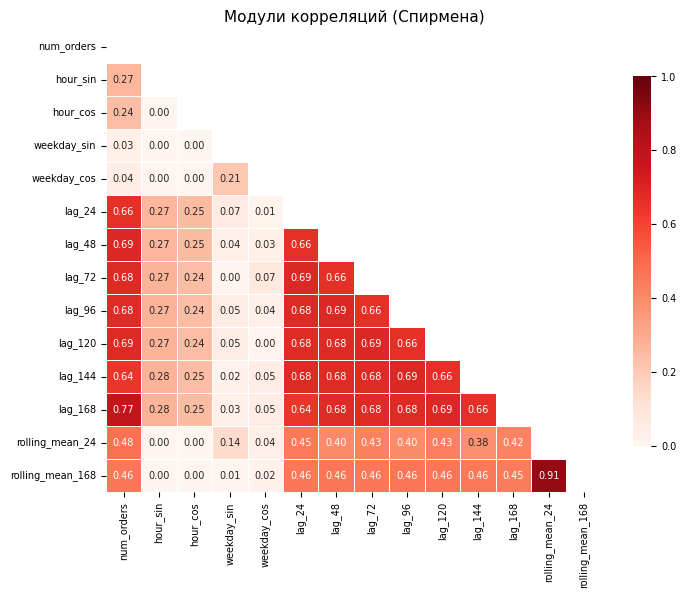

In [61]:
heatmap_show(abs(corr_matrix_s),
             graph_title='Модули корреляций (Спирмена)',
             figsize=(8, 6),
             font_size=7,
             cmap='Reds',
             lower_triangle=True)

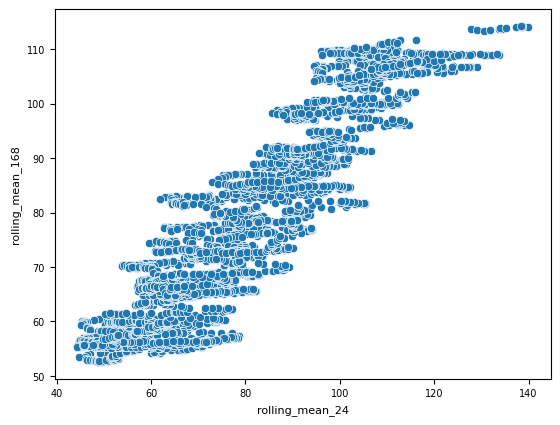

In [62]:
sns.scatterplot(x=X_train['rolling_mean_24'],
                y=X_train['rolling_mean_168']);

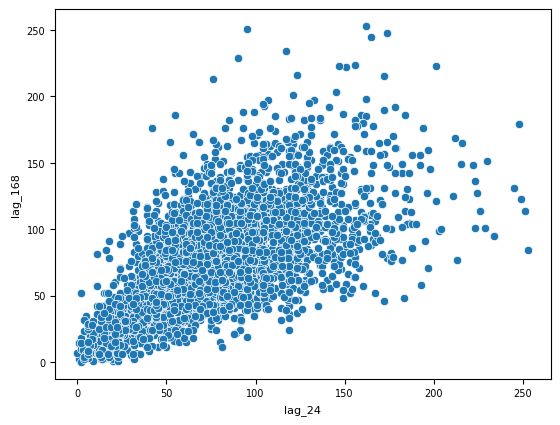

In [63]:
sns.scatterplot(x=X_train['lag_24'],
                y=X_train['lag_168']);

**Выводы - анализ корреляций**:

---
1. *Корреляции предикторов с целевой переменной*:
- закодированный признак дня недели (`weekday_sin/weekday_cos`) <u>слабо коррелирован</u> с целевой переменной (сумма двух к-тов коррелляции менее 0.1);
- максимальная корреляция предикторов с целевой переменной составляет 0.77 (предиктор: `lag_168`).

---
2. *Корреляции предикторов между собой, возможные утечки данных*:
- пара `rolling_mean_168` и `rolling_mean_24`:
  - парная корреляция 0.91;
  - это естественного вида высокая корреляция (т.к. просто берем скользящее среднее на разном окне);
  - <u>один из признаков - кандидат на удаление из набора пременных</u>;
- пары лаговых признаков (все):
  - парные корреляции порядка 0.66-0.69;
  - это естественного вида высокая корреляция (т.к. берутся последовательные лаги с разницей в сутки - 24 часа);
  - прямой утечки данных здесь нет (см. график выше);
  - <u>все признаки оставляем в наборе переменных</u>.

---
**Резюме**:
- признаки с малой корреляцией с таргетом:
  - могут быть значимы для нелинейных моделей в комбинации с иными признаками;
  - но, могут быть и удалены из набора переменных;
- признаки с высокоми взаимными корреляциями:
  - могут быть и удалены из набора переменных (один признак из двух в каждой паре).

## Анализ мультиколлинеарности

***Принципы анализа следующие***:

- рассчитываем число обусловленности матрицы корреляций начального набора входных признаков;
- исключаем часть входных признаков (обозначенных на этапе корреляционного анализа - см. выше);
- рассчитываем число обусловленности матрицы корреляций после исключения части входных признаков;
- сравниваем показатели до и после исключения признаков и делаем выводы.

---
*Принята следующая градация степени мультиколлинеарности (Belsley, D. A., Kuh, E., & Welsch, R. E. (1980) — Regression Diagnostics: Identifying Influential Data and Sources of Collinearity)*:

| Диапазон числа обусловленности | Степень мультиколлинеарности | Интерпретация |
|:---------------:|:-------------:|:----------------:|
| 1 ≤ cond < 10 | Отсутствует / Слабая | Норма для моделирования. Нет серьезных проблем с интерпретацией коэффициентов. |
| 10 ≤ cond < 30 | Умеренная | Возможны нестабильности в оценках. Требует внимания при интерпретации. |
| ≥ 30 | Сильная | Критическая мультиколлинеарность. Риск численной неустойчивости прогноза. |

In [65]:
# список числовых переменных
num_cols = X_train.select_dtypes(include=['number']).columns.tolist()
print(num_cols)

# список категориальных переменных
cat_cols = X_train.select_dtypes(exclude=['number']).columns.tolist()
print(cat_cols)

['hour_sin', 'hour_cos', 'weekday_sin', 'weekday_cos', 'lag_24', 'lag_48', 'lag_72', 'lag_96', 'lag_120', 'lag_144', 'lag_168', 'rolling_mean_24', 'rolling_mean_168']
[]


**Расчет по начальному набору переменных.**

In [66]:
cols_filtered_0 = num_cols + cat_cols

# список
print(f"Список переменных - все:\n{cols_filtered_0}")

Список переменных - все:
['hour_sin', 'hour_cos', 'weekday_sin', 'weekday_cos', 'lag_24', 'lag_48', 'lag_72', 'lag_96', 'lag_120', 'lag_144', 'lag_168', 'rolling_mean_24', 'rolling_mean_168']


In [67]:
# фильтруем матрицу корреляций и считаем число обусловленности
filtered_matrix = corr_matrix_s.loc[cols_filtered_0, cols_filtered_0]

# Вычисляем число обусловленности
condition_number = round(np.linalg.cond(filtered_matrix.to_numpy(), p=2),2)

print(f"Число обусловленности матрицы корреляций входных признаков"
      f"\nначальный набор переменных: {condition_number}")

Число обусловленности матрицы корреляций входных признаков
начальный набор переменных: 80.11


**Расчет по отфильтрованному набору переменных - 1.**

In [68]:
# переменные, которые можно исключить из модели
# сильная взаимная корреляция в паре предикторов
# удалем переменную и пары, у которой меньше модуль корреляции с таргетом
cols_to_exclude_1 = ['rolling_mean_168']

In [69]:
cols_filtered_1 = [col for col in cols_filtered_0 if col not in cols_to_exclude_1]

# список
print(f"Список переменных - после удаления части предикторов:\n{cols_filtered_1}")

Список переменных - после удаления части предикторов:
['hour_sin', 'hour_cos', 'weekday_sin', 'weekday_cos', 'lag_24', 'lag_48', 'lag_72', 'lag_96', 'lag_120', 'lag_144', 'lag_168', 'rolling_mean_24']


In [70]:
# фильтруем матрицу корреляций и считаем число обусловленности
filtered_matrix = corr_matrix_s.loc[cols_filtered_1, cols_filtered_1]

# Вычисляем число обусловленности
condition_number = round(np.linalg.cond(filtered_matrix.to_numpy(), p=2),2)

print(f"Число обусловленности матрицы корреляций входных признаков"
      f"\nпосле исключения на первом этапе: {condition_number}")

Число обусловленности матрицы корреляций входных признаков
после исключения на первом этапе: 21.2


**Расчет по отфильтрованному набору переменных - 2.**

In [71]:
# переменные, которые можно исключить из модели
# откровенно слабые корреляции с таргетом
cols_to_exclude_2 = low_corr_on_target['Feature'].unique().tolist()

In [72]:
cols_filtered_2 = [col for col in cols_filtered_1 if col not in cols_to_exclude_2]

# список
print(f"Список переменных - после удаления части предикторов:\n{cols_filtered_2}")

Список переменных - после удаления части предикторов:
['hour_sin', 'hour_cos', 'lag_24', 'lag_48', 'lag_72', 'lag_96', 'lag_120', 'lag_144', 'lag_168', 'rolling_mean_24']


In [73]:
# фильтруем матрицу корреляций и считаем число обусловленности
filtered_matrix = corr_matrix_s.loc[cols_filtered_2, cols_filtered_2]

# Вычисляем число обусловленности
condition_number = round(np.linalg.cond(filtered_matrix.to_numpy(), p=2),2)

print(f"Число обусловленности матрицы корреляций входных признаков"
      f"\nпосле исключения на втором этапе: {condition_number}")

Число обусловленности матрицы корреляций входных признаков
после исключения на втором этапе: 20.11


**Вывод - мультиколлинеарность входных признаков**.

Динамика числа обусловленности матрицы корреляций при последовательном исключении признаков:
- начальный набор признаков: 80.11;
- после исключения сильных взаимных корреляций предикторов: 21.2 (<u>существенное снижение показателя</u>);
- после предикторов с очень малыми корреляциями с таргетом: 20.11 (<u>НЕсущественное снижение показателя</u>).

## Выводы - подготовка данных для ML

---
На основании анализа сезонности в данных и иных особенностей исходного временного ряда введем следующие дополнительные переменные в исходных датасет:

*Циклические переменные*:
- введены циклические временные переменные по дням недели и часам в сутках;
- эти новые переменные закодированы тригонометрическими фукнциями (через `sin/cos`);

*Временные лаги*:
- введены временные лаговые переменные в соотвествии с найдейнной сезонностью в данных;
- временной лаг начинается с 24 часов (сутки), увеличивается с шагом 24 часа, заканчивается 168 часах (неделя);

*Скользящие средние*:
- введено скользящее среднее;
- окна усреднения: 24 часа (сутки) и 168 часов (неделя);

---
*Корреляции предикторов с целевой переменной*:
- закодированный признак дня недели (`weekday_sin/weekday_cos`) <u>слабо коррелирован</u> с целевой переменной (сумма двух к-тов коррелляции менее 0.1);
- максимальная корреляция предикторов с целевой переменной составляет 0.77 (предиктор: `lag_168`).

*Корреляции предикторов между собой, возможные утечки данных*:
- пара `rolling_mean_168` и `rolling_mean_24`:
  - парная корреляция 0.91;
  - это естественного вида высокая корреляция (т.к. просто берем скользящее среднее на разном окне);
  - <u>один из признаков можно отбросить</u>;
- пары лаговых признаков (все):
  - парные корреляции порядка 0.66-0.69;
  - это естественного вида высокая корреляция (т.к. берутся последовательные лаги с разницей в сутки);
  - прямой утечки данных здесь нет (см. график выше);
  - <u>все признаки оставляем в наборе переменных</u>.

---
***Главные выводы***:

- признаки с малой корреляцией с таргетом:
  - могут быть значимы для нелинейных моделей в комбинации с иными признаками;
  - при исключении из набора переменных слабо влияют на уровень мультиколлинеарности;
  - будут оставлены в наборе переменных;
- признаки с высокими взаимными корреляциями:
  - при исключении из набора переменных сильно снижают уровень мультиколлинеарности;
  - из пары высококоррелириованных признаков один исключается (тот у которого меньше модель корреляции с таргетом).
- мультиколлинеарность набора входных признаков:
  - чсило обусловленности матрицы корреляций итогового набора признаков (21.2) показывает повышенный уровень мультиколлинеарности, что является фактором настораживающим;
  - для линейных моделей нужно использовать модели с регулярегизацией;
  - для нелинейных моделей фактор мультиколлинеарности может не играть решающей роли и не снижать обобщающую способность моделей.

# Построение моделей ML

## Описание процесса построения моделей ML

---
**Цель**:
- построить модель машинного обучения (ML) для предсказания числа заказов такси на следующий час.

---
**Описание решения**:

- Целевая переменная: `num_orders` — целочисленная.
- Задача: решается задача прогнозирования временного ряда (задача регрессии).
- Методы: Модели ML строятся с использованием следующих алгоритмов:
  - Линейная модель (Linear Regression с регуляризацией, например - Ridge).
  - Случайный лес (RandomForestRegressor).
- Подбор гиперпараметров: Для каждой модели используется пайплайн, объединяющий предобработку данных и обучение, с последующим перебором гиперпараметров (например, RandomizedSearchCV).
- Оценка качества: Обучение и подбор гиперпараметров проводятся с использованием кросс-валидации; кросс-валидация учитывает, что целевая переменная это временной ряд; целевая метрика качества прогноза - RMSE (д.б. не более 48).

## Общие константы и переменные

In [74]:
# Формируем набор признаков - окончательный
# при разбиении на выборки - начало тестовой выборки будет ровно там же
# где и было изначально (при выделении train-выборки для анализа данных)
X_train, X_test, y_train, y_test = prepare_features_and_split(
    df_h,
    test_size=TEST_SIZE,
    target_col=target_col,
    lags_to_create=list(range(24, 24 * 7 + 1, 24)),
    rolling_windows=[24] # удалено скользящее среднее на периоде 168 часов
);

Оригинальный размер Трейна: 3975, Теста: 441
Фактический размер X_train: 3807, X_test: 441


In [75]:
# Формируем списки колонок автоматически из X_train
num_cols_model = X_train.select_dtypes(include=['number']).columns.tolist()

# Исключаем целевую из числовых признаков, если она там оказалась
num_cols_model = [col for col in num_cols_model if col != target_col]

cat_cols_model = X_train.select_dtypes(exclude=['number']).columns.tolist()

# Исключаем целевую из категориальных признаков, если она там оказалась
cat_cols_model = [col for col in cat_cols_model if col != target_col]

print(f"Целевая пременная:\n {target_col}")
print(f"Числовые колонки (num_cols_model):\n {num_cols_model}")
print(f"Категориальные колонки (cat_cols_model):\n {cat_cols_model}")

Целевая пременная:
 num_orders
Числовые колонки (num_cols_model):
 ['hour_sin', 'hour_cos', 'weekday_sin', 'weekday_cos', 'lag_24', 'lag_48', 'lag_72', 'lag_96', 'lag_120', 'lag_144', 'lag_168', 'rolling_mean_24']
Категориальные колонки (cat_cols_model):
 []


**Важно**:

В расчетах метрики обучения/валидации (RMSE) и метрики качества (тоже RMSE) нужно учесть, что целевая переменная целочисленная (число заказов в такси за час), поэтому пишем свой скорер, где округляем прогнозные значения целевой переменной до целого.

In [76]:
# Константы - для единообразия режимов обучения
n_iter_ = 20 # число итераций для RandomizedSearchCV

# Используем TimeSeriesSplit для учета последовательности во временных рядах
cv_time_series = TimeSeriesSplit(n_splits=5)

In [77]:
# Создаем свой скорер для sklearn
rmse_scorer = make_scorer(rmse_rounded, greater_is_better=False)

## Построение пайплайна

*Составляем пайплайн где разделяем шаги*:
- разные типы входных признаков обрабатываем по разному;
- все категориальные переменные кодируем используя `OneHotEncoder`;
- все числовые переменные - стандартизируем используя `StandardScaler`.

In [78]:
# пайплайн для подготовки признаков из списка cat_cols:
# заполнение пропусков и OHE-кодирование
# SimpleImputer + OHE
ohe_pipe = Pipeline([
    ('simpleImputer_before_ohe', SimpleImputer(missing_values=np.nan,
                                               strategy='most_frequent')),
    ('ohe', OneHotEncoder(drop='first',
                          handle_unknown='ignore',
                          sparse_output=False)),
    ('simpleImputer_after_ohe', SimpleImputer(strategy='constant',
                                              fill_value=0))
])

In [79]:
# общий пайплайн для подготовки данных
data_preprocessor = ColumnTransformer(
    [('ohe', ohe_pipe, cat_cols_model),
     ('num', StandardScaler(), num_cols_model)
    ], remainder='drop')

## Параметры для моделей ML

In [80]:
# Определение моделей и их параметров
model_configs = {
    'ElasticNet': {
        'pipeline': Pipeline([
            ('preprocessor', data_preprocessor),
            ('models', ElasticNet(
                    alpha=1.0,
                    l1_ratio=0.5,
                    random_state=RANDOM_STATE,
                    max_iter=1000,
                    tol=1e-4
            ))
        ]),
        'param_grid': {
            'models__alpha': np.logspace(-4, 4, 9),
            'models__l1_ratio': np.linspace(0.0, 1.0, 11)
        }
    },
    'RandomForest': {
        'pipeline': Pipeline([
            ('preprocessor', data_preprocessor),
            ('models', RandomForestRegressor(
                n_estimators=100,
                random_state=RANDOM_STATE,
                n_jobs=-1,
                verbose=0,
                max_depth=None,
                min_samples_split=2,
                min_samples_leaf=1,
                max_features='sqrt',
            ))
        ]),
        'param_grid': {
            'models__n_estimators': [200, 300, 400, 500],
            'models__max_depth': [None, 5, 10, 15, 20],
            'models__min_samples_split': [2, 5, 10],
            'models__min_samples_leaf': [1, 2, 4, 6],
            'models__max_features': ['sqrt', 'log2', None]
        }
    }
}

## Обучение моделей ML

In [81]:
# Цикл по конфигурациям моделей
for model_name, config in model_configs.items():
    print(f"\nОбработка модели: {model_name}")

    # Создание RandomizedSearchCV
    search_cv = RandomizedSearchCV(
        config['pipeline'],
        param_distributions=config['param_grid'],
        n_iter=n_iter_,
        cv=cv_time_series,
        scoring=rmse_scorer,
        n_jobs=-1,
        random_state=RANDOM_STATE
    )

    # Обучение модели
    search_cv.fit(X_train, y_train.values.ravel())

    # Получение лучшей модели
    best_model = search_cv.best_estimator_

    models_results[model_name] = {}
    models_results[model_name]['best_model'] = best_model

    # Метрика на кросс-валидации (среднее значение)
    cv_score_mean = -search_cv.cv_results_["mean_test_score"][
        search_cv.best_index_
    ]  # Отрицание, т.к. scorer отрицательный
    models_results[model_name]["cv_mean_rmse"] = cv_score_mean

    # Метрика на последних значениях обучающей выборки (по длине тестовой)
    last_train_len = len(X_test)
    X_train_last = X_train.iloc[-last_train_len:] # Последние строки X_train
    y_train_last = y_train.iloc[-last_train_len:] # Соответствующие целевые значения

    y_pred_on_train_last = best_model.predict(X_train_last)
    y_pred_on_train_last_rounded = np.round(y_pred_on_train_last).clip(0) # округление
    train_last_rmse = rmse_rounded(y_train_last, y_pred_on_train_last_rounded)

    models_results[model_name]['train_last_rmse'] = train_last_rmse

    print(f"  - Параметры модели : {search_cv.best_params_}")
    print(f"  - CV RMSE (среднее): {cv_score_mean:.2f}")
    print(f"  - Train Last RMSE  : {train_last_rmse:.2f}")


Обработка модели: ElasticNet
  - Параметры модели : {'models__l1_ratio': np.float64(0.1), 'models__alpha': np.float64(0.1)}
  - CV RMSE (среднее): 22.14
  - Train Last RMSE  : 28.90

Обработка модели: RandomForest
  - Параметры модели : {'models__n_estimators': 500, 'models__min_samples_split': 5, 'models__min_samples_leaf': 1, 'models__max_features': 'sqrt', 'models__max_depth': 10}
  - CV RMSE (среднее): 21.97
  - Train Last RMSE  : 17.60



Название модели: ElasticNet


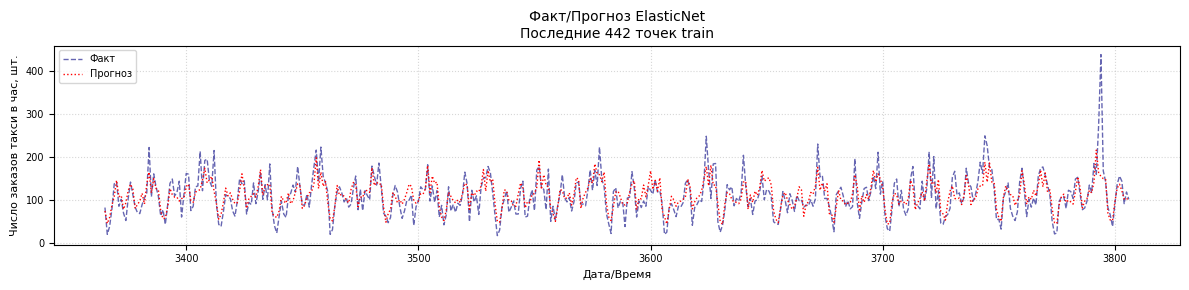

  - Train Last RMSE (обновлено): 28.87

Название модели: RandomForest


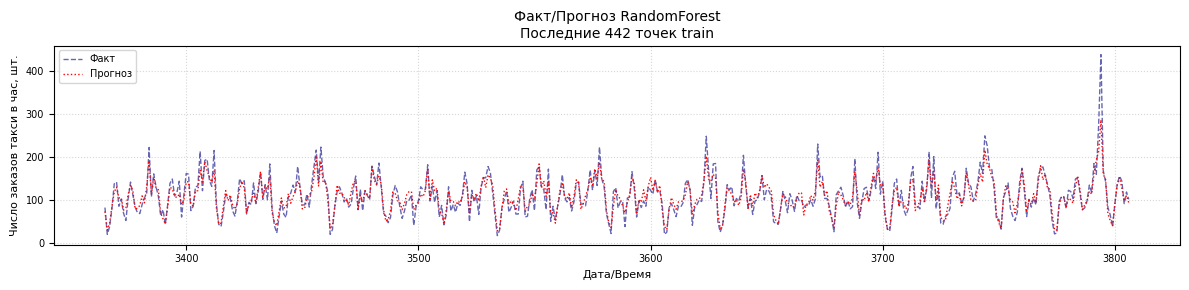

  - Train Last RMSE (обновлено): 17.58


In [83]:
# Вывод прогнозов и метрик для обученных ML-моделей (на последних n_test точках train)
last_train_len = n_test
X_train_last = X_train.iloc[-last_train_len:]
y_train_last = y_train.iloc[-last_train_len:]

for model_key, model_info in models_results.items():
    # Проверяем, нужно ли исключить текущую модель
    if model_key in ('SARIMAX_211_111_24', 'Naive_Seasonal_Weekly'):
        continue  # Переходим к следующей итерации цикла, пропуская код ниже
    if 'best_model' in model_info and hasattr(model_info['best_model'], 'predict'):
        print(f"\nНазвание модели: {model_key}")
        best_ml_model = model_info['best_model']

        # Прогноз
        y_pred_on_train_last = best_ml_model.predict(X_train_last)
        y_pred_on_train_last_rounded = np.round(y_pred_on_train_last).clip(0)

        # Преобразование в Series с правильным индексом
        forecast_series = pd.Series(y_pred_on_train_last_rounded,
                                    index=y_train_last.index)

        # Визуализация
        plot_ts_forecast_graph(
            y_train_last, forecast_series, # Передаем Series
            figsize=(12, 3),
            name_model=f"Факт/Прогноз {model_key}\nПоследние {n_test} точек train",
            name_x='Дата/Время',
            name_y='Число заказов такси в час, шт.'
        )

        # Пересчет метрики
        train_last_rmse_ml = rmse_rounded(y_train_last, forecast_series)

        # Обновление словаря
        model_info['train_last_rmse'] = train_last_rmse_ml

        # Вывод
        print(f"  - Train Last RMSE (обновлено): {train_last_rmse_ml:.2f}")

# Лучшая модель

## Выбор лучшей модели

При выборе лучшей модели будем опираться основную метрику:
- `RMSE` на кросс-валидации или всей обучающей выборке;
- `RMSE` на самых свежих по времени данных из обучающей выборки (по длине срез данных равен размеру тестовой выборки).

Ниже приводится сводная таблица итогов обучения и валидации моделей.

In [84]:
# DataFrame из словаря результатов моделей
df_models_results = pd.DataFrame.from_dict(models_results, orient='index')

display(df_models_results[['train_all_rmse', 'cv_mean_rmse', 'train_last_rmse']])

,train_all_rmse,cv_mean_rmse,train_last_rmse
Naive_Seasonal_Weekly,25.826,NaN,33.993
SARIMAX_211_111_24,22.194,NaN,29.165
ElasticNet,NaN,22.140,28.866
RandomForest,NaN,21.972,17.585


По совокупности метрик:
- по метрике RMSE на кросс-валидации/всей train выборке:
  - сопоставимые результаты дали все модели, кроме `Naive_Seasonal_Weekly` у которой метрика хуже остальных трех моделей;
- по метрике RMSE на "правой" части обучающей выборки (длиной такая же как тестовая выборка):
  - явно выигрывает у прочих `RandomForest`.
 
Итоговый выбор:
- лучшая модель: `RandomForest` имеет лучшие метрики RMSE;
- ниже проведем тестирование этой модели (прогон на тестовой выборке).

## Тестирование лучшей модели

In [85]:
# фиксируем лучшую модель
final_model = df_models_results.loc['RandomForest', 'best_model']
print(final_model)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('ohe',
                                                  Pipeline(steps=[('simpleImputer_before_ohe',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False)),
                                                                  ('simpleImputer_after_ohe',
                                                                   SimpleImputer(fill_value=0,
                                                                                 strategy='constant'))]),
                                

In [86]:
# Предсказания на тестовой выборке
y_test_pred = np.round(final_model.predict(X_test), 0).clip(0)

In [87]:
# Метрики
test_rmse_final = rmse_rounded(y_test, y_test_pred)

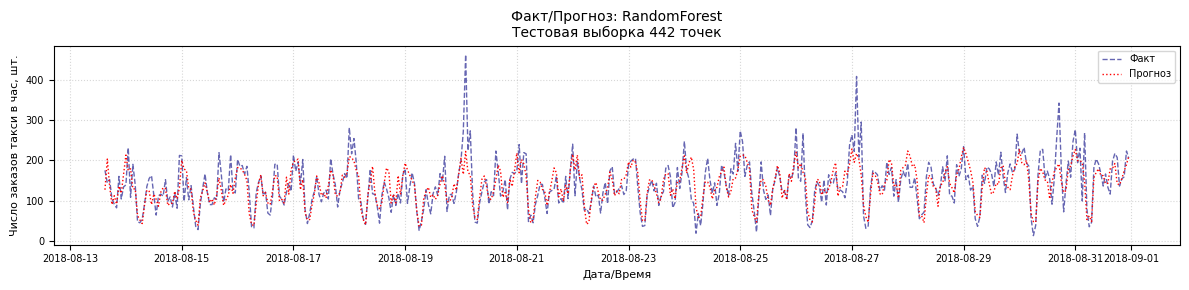

In [88]:
y_test_pred = pd.Series(y_test_pred, index=y_test.index)
# Визуализация
plot_ts_forecast_graph(
    y_test, y_test_pred,
    figsize=(12, 3),
    name_model=f"Факт/Прогноз: RandomForest\nТестовая выборка {n_test} точек",
    name_x='Дата/Время',
    name_y='Число заказов такси в час, шт.'
)

Лучшая модель: RandomForest
RMSE (тест): 36.99


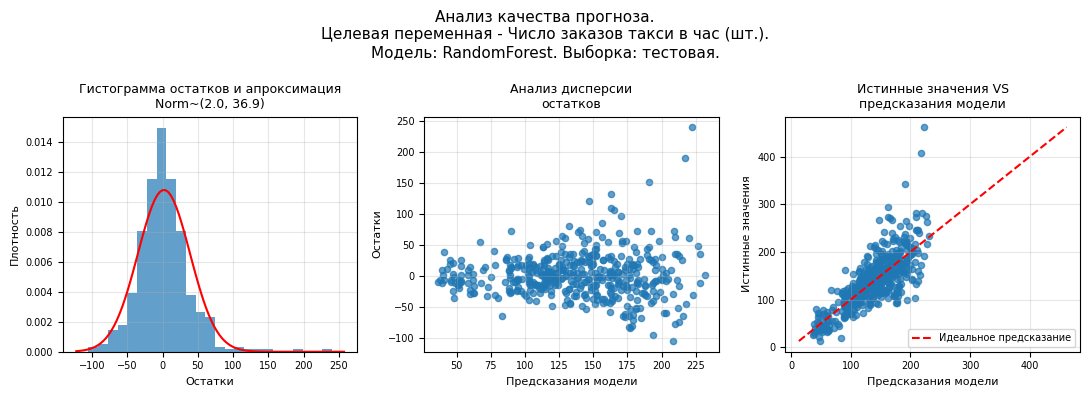

In [89]:
# выводим результаты
display(HTML("<div style='border-bottom: 2px solid green; margin: 10px 0;'></div>"))
print(f"Лучшая модель: RandomForest")

print(f"RMSE (тест): {test_rmse_final:.2f}")

# визуализация результатов
reg_quality_analize(
    y_true=y_test,
    y_pred=y_test_pred,
    target='Число заказов такси в час (шт.)',
    set_name = 'тестовая',
    model_name = (f"Модель: RandomForest")
)

**Визуализация важности признаков**

In [90]:
# Извлекаем модель и препроцессор из пайплайна
fin_model = final_model.named_steps['models']
preprocessor = final_model.named_steps['preprocessor']

# Получаем важность признаков из модели
feature_importances = fin_model.feature_importances_

# Получаем имена признаков после препроцессинга (StandardScaler)
num_scaler = preprocessor.named_transformers_['num']  # Извлекаем StandardScaler

num_feature_names = num_cols_model

# Объединяем имена признаков в правильном порядке
feature_names = list(num_feature_names)

# Создаем DataFrame для отображения
# ВАЖНО: len(feature_names) должен совпадать с len(feature_importances)
if len(feature_names) != len(feature_importances):
    print(f"Предупреждение: количество признаков ({len(feature_names)}) "
          f"не совпадает с количеством импортансов ({len(feature_importances)}).")
    print("Возможная причина: несоответствие в определении cat_cols_model "
          "или num_cols_model.")
else:
    importance_df = pd.DataFrame({
        'feature': feature_names,
        'importance': feature_importances
    }).sort_values(by='importance', ascending=False)

# Выводим таблицу - 1
print(f"ТОП-10 важных признаков - после OHE-кодирования:\n")
display(importance_df.head(10))

# Инициализируем словарь для хранения суммарной важности
aggregated_importance = {}

# Добавляем числовые признаки (их важность не меняется после StandardScaler)
for num_col in num_cols_model:
    # Находим важность для числового признака
    imp_value = importance_df[importance_df["feature"] == num_col]["importance"].iloc[0]
    aggregated_importance[num_col] = imp_value

# Создаем финальный DataFrame
final_importance_df = pd.DataFrame(
    list(aggregated_importance.items()),
    columns=['feature', 'importance']
).sort_values(by='importance', ascending=False)

print(f"\nВажность всех признаков - без OHE-кодирования:\n")
display(final_importance_df)

ТОП-10 важных признаков - после OHE-кодирования:



,feature,importance
10,lag_168,0.281
5,lag_48,0.128
7,lag_96,0.113
6,lag_72,0.110
8,lag_120,0.107
4,lag_24,0.079
11,rolling_mean_24,0.058
9,lag_144,0.044
0,hour_sin,0.037
1,hour_cos,0.022



Важность всех признаков - без OHE-кодирования:



,feature,importance
10,lag_168,0.281
5,lag_48,0.128
7,lag_96,0.113
6,lag_72,0.110
8,lag_120,0.107
4,lag_24,0.079
11,rolling_mean_24,0.058
9,lag_144,0.044
0,hour_sin,0.037
1,hour_cos,0.022


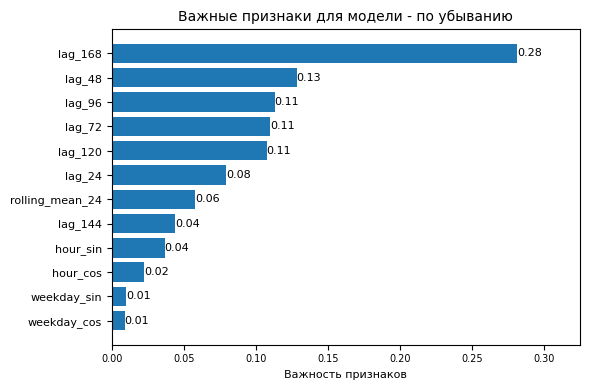

In [91]:
# Простая визуализация
top_k = min(15, len(final_importance_df))
fig, ax = plt.subplots(figsize=(6, 4))

bars = ax.barh(range(top_k), final_importance_df['importance'].head(top_k))

# Добавляем подписи данных справа от баров
for i, bar in enumerate(bars):
    width = bar.get_width()
    ax.text(width, bar.get_y() + bar.get_height()/2., f'{width:.2f}',
            ha='left', va='center', fontsize=8)

ax.set_yticks(range(top_k))
ax.set_yticklabels(final_importance_df['feature'].head(top_k), fontsize=8)
ax.set_xlabel('Важность признаков')
ax.set_title('Важные признаки для модели - по убыванию', fontsize=10)
ax.invert_yaxis()  # Самый важный признак наверху

# Увеличиваем диапазон значений на горизонтальной оси на 10%
max_val = ax.get_xlim()[1]
ax.set_xlim(0, max_val * 1.1)

plt.tight_layout()
plt.show()

***Выводы по тестированию лучшей модели***:
- целевая метрика удовлетворяет условию задания: RMSE = 36.99 < 48;
- структура остатков при прогнозировании относительно неплохая, но не идеальная; при увеличении целевой переменной сверх примерно 180-200 дисперсия остаков растет, точноть прогноза снижается;
- по визуализации прогнозов на тестовой выборке:
  - <u>модель чаще ошибается при прогнозировании высоких/пиковых значений</u> числа заказов (более 180-200 в час);
  - т.е. модель не всегда точно улавливает разовые пиковые выбросы вверх.

***Выводы по важности прознаков***:
- лаговые признаки - наиболее важные для модели;
- самый важный признак: `lag_168` - значение целевой переменной неделю назад (что хорошо согшласуется с недельной сезонностью в данных);
- наименее важные признаки: кодированные (через sin/cos) значения дней недели.

***Важные дополнения***:
- CV RMSE=21.97, а Test RMSE=36.99 — разрыв в ~15 единиц - это существенно;
- вероятная причина: в августе (тестовый период) число заказов продолжает расти (есть восходящий тренд в данных), и модель, обученная преимущественно на данных марта–июля, систематически недооценивает пиковые значения;
- это ограничение модели.

# Итоги, выводы, рекомендации

## Описание задачи

**Задачи исследования**

Необходимо построить модель для прогнозирования количества заказов такси в аэропортах на следующий час.

---
**Описание датасета**

В нашем распоряжении есть исторические данные о заказах такси в аэропортах.

Данные получаем из файла: `taxi.csv`

Структура данных:

- Количество заказов находится в столбце num_orders (от англ. number of orders, «число заказов»).

---
**Ход исследования**:

1. Первичная обработка данных.
2. Ресемплирование данных по 1 часу, изоляция тестовой выборки (10% от данных).
3. Исследовательский анализ данных.
4. Прогнозирование без машинного обучения:
  - `прогноз данными недельной давности`,
  - моделирование `SARIMAX`.

5. Подготовка данных для ML-моделей:
  - ввод новых переменных,
  - корреляционный анализ данных,
  - анализ мультиколлинеарности,
  - итоговый набор предикторов.

6. Построение моделей ML:
- `ElacticNet` линейная модель с регуляризацией;
- `RandomForestRegressor` нелинейная модель на основе деревьев.

7. Оценка качества моделей, выбор лучшей модели:
  - для выбора лучшей модели опираемся на метрику RMSE;
  - допустимое значение метрики RMSE - менее 48.

8. Тестирование лучшей модели:
- тестируем лучшую модель на тестовой выборке;
- допустимое значение метрики RMSE на тесте - менее 48.

9. Итоги, выводы, рекомендации:
- на лучшей модели предсказывается число заказов такси в аэропортах на следующий час;
- делаются выводы и рекомендации.

## Первичная обработка данных

**Что сделано**:

| Название | Факт/Действие |
|:-----------:|:---------------------------:|
|Названия столбцов | Приведены к 'змеиному регистру' в колонке даты/времени.|
|Типы данных | Данные о дате/времени переведены в формат `datetime64[ns]`.|
|Пропуски в данных | Не выявлены.|
|Неявные дубликаты в данных | Не выявлены. |
|Явные дубликаты в данных | Не выявлены. |

## Подготовка данных

**Что сделано**:

Согласно задания - проведено ресемлирование данных по периоду в 1 час.

Добавлены новые переменные:
- номер часа в сутках (от 0 до 23);
- номер дня недели (0 - пн., 6 - вс.);
- новые переменные переведены в тип `Category (Ordered)`- т.е. категориальные переменные, имеющие заданные порядки значений.

Данные разделены на обучающую и тестовую выборки, при этом:
- согласно ТЗ размер тестовой выборки 10% от объема данных;
- важно: сохранен хронологический порядок данных при разделении (тестовая выборка - строго в конце датасета);
- *таким образом, тестовая выборка изолируется от обучающей и используется только на этапе тестирования финальной модели*.

## Исследовательский анализ данных

**Что сделано**:

- исследована стационарность временного ряда;
- исследована сезонность временного ряда.

Поскольку у нас есть данные только за март-август 2018 года, то выделять ежемесячную сезонность в данных не имеет смысла (т.к. у нас нет данных за несколько лет и мы не можем сравнивать соотвествующие месяцы в разных календарных годах).

Стационарность, автокорреляции:
- по тесту Дики-Фуллера: исходный ряд вероятно стационарен;
- по графикам автокорреляции: явно видна сезонность в данных; сезонность кратна 24 часам.

Из графиков визуализации сезонности видно, что:
- *есть сезонность внутри суток*, например:
  - в период с 5:00 до 7:59 среднее число заказов в сутках минимально;
  - в период с 0:00 до 00:59 среднее число заказов близко к максимальным значениям;
  - эти факты наблюдаются практически независимо от дня недели;
- *сезонность внутри суток комбинируется с сезонностью по дням недели*, например:
  - среднее число заказов близкое к максимальным значениям наблюдается с 0:00 до 00:59 в пн. и сб., а также с 22:00 до 23:00 в пт.
- при выделении суточной сезонности в часовых данных:
  - распределение остатков: в целом близко к нормальному, есть некоторое число выбросов в правом хвосте распределения;
  - выделенный тренд: имеет внутри себя явно видимую неучтенную сезонность;
  - ряд остатков: стационарен;
- при выделении недельной сезонности часовых в данных:
  - распределение остатков: в целом близко к нормальному, есть некоторое число выбросов в правом хвосте распределения;
  - выделенный тренд: не имеет внутри себя явной видимой неучтенной сезонности (хотя она там возможно и есть на помесячных данных);
  - ряд остатков: стационарен.

***Выводы***:
- исходный ряд стационарен (по тесту Дики-Фуллера); *можно использовать исходный ряд для построение моледей ML*;
- в исходном ряду присутствует сезонность; сезонность кратна 24 часам; при построении прогнозов необходимо учитывать наличие *ежесуточной + еженедельной сезонности в часовых данных по заказам такси*.

***Дополнительные соображения - трендовая компонента***:
- из графиков декомпозиции видно, что с марта по август 2018 года наблюдается умеренный восходящий тренд (рост числа заказов); это важно для понимания поведения итоговой модели на тестовом периоде, который является «самым свежим» по времени;
- поэтому разница между метриками при кросс-валидации и тесте, не обязательно будет объясняться только переобучением модели.

## Прогнозирование - без ML

**Что сделано**:

- проведено т.н. "наивное" прогнозирование значений временного ряда (значением на неделю назад);
- проведено моделирование с использованием SARIMAX.

---
1. 'Наивное' прогнозирование:

Проведено т.н. "наивное" прогнозирование значений временного ряда таким способом:
- число заказов такси на следующий час прогнозируется как соотвествующее значение на несколько часов тому назад;
- период временного "сдвига" при прогнозе:
  - начинается с 24 часов, принимается кратным 24 часам (сутки), максимум - 168 часов (неделя);
- метрика для выбора оптимального периода сезонности/сдвига: RMSE на обучающей выборке.

***Выводы***:
- наилучший результат показывает прогноз со сдвигом на неделю (168 часов назад);
- в целом наивный прогноз исторически неплохо попадает в фактические значения, однако ближе к концу обучающей выборки плохо улавливает пиковые выбросы числа заказов (выбросы вверх);
- лучшая метрика RMSE получена на варианте прогноза значением на неделю назад (-168 часов от прогнозного часа);
- <u>целевая метрика удовлетворяет условию задания</u>:
  - по всей обучающей выборке: `RMSE = 25.83 < 48`;
  - по последним точкам обучающей выборки (размер окна прогнорза = размеру тестовой выборки): `RMSE = 33.99 < 48`.

---
2. Модель `SARIMA (2, 1, 1)(1, 1, 1, 24)` - лучшая по всем метрикам.

2.1. Структура модели:
- `SARIMAX(2, 1, 1)x(1, 1, 1, 24)`
- Несезонная часть: `(2, 1, 1)`
  - p=2: Авторегрессионная компонента второго порядка. Текущее значение зависит от двух предыдущих значений ряда (после несезонной разности).
  - d=1: Одна несезонная разность применена для достижения стационарности.
  - q=1: Скользящее среднее первого порядка. Ошибка прогноза на один шаг зависит от одной предыдущей ошибки.
- Сезонная часть: `(1, 1, 1, 24)`
  - P=1: Сезонная авторегрессия первого порядка. Текущее значение (после разностей) зависит от значения 24 периода назад (после разностей).
  - D=1: Одна сезонная разность применена к уже несезонно-разностному ряду для устранения сезонной интеграции.
  - Q=1: Сезонное скользящее среднее первого порядка. Сезонная ошибка прогноза зависит от одной предыдущей сезонной ошибки (с лагом 24).
  - m=24: Период сезонности (24 часа).

2.2. Точность прогноза:
- в целом SARIMAX исторически неплохо попадает в фактические значения, однако иногда плохо улавливает пиковые выбросы числа заказов (выбросы вверх);
- <u>целевая метрика удовлетворяет условию задания</u>:
  - по всей обучающей выборке: `RMSE = 22.19 < 48`;
  - по последним точкам обучающей выборки (размер окна прогнорза = размеру тестовой выборки): `RMSE = 29.17 < 48`.


***Выводы по модели***:
- Модель `SARIMAX(2, 1, 1)x(1, 1, 1, 24)` показала лучший AIC среди рассмотренных. Она учитывает сложную структуру данных:
  - Тренд (d=1) и сезонную интеграцию (D=1).
  - Несезонную динамику через AR(2) и MA(1).
  - Сезонную динамику через SAR(1) и SMA(1).
- Диагностика остатков показывает, что автокорреляция в остатках устранена (Ljung-Box Test), что говорит о хорошей адаптации модели к данным. Однако остатки не нормальны и гетероскедастичны. Это не делает модель плохой для прогнозирования, но указывает на то, что доверительные интервалы и статистические тесты для параметров могут быть менее надежными.
- С точки зрения RMSE, модель показывает приемлемые по условию задания ошибки.

## Подготовка данных для обучения моделей

**Что сделано и какие результаты/выводы получены**.

---
***Новые переменные***

На основании анализа сезонности в данных и иных особенностей исходного временного ряда введены следующие дополнительные переменные в исходный датасет:

1. *Циклические переменные*:
- введены циклические временные переменные по дням недели и часам в сутках;
- эти новые переменные закодированы тригонометрическими фукнциями (через `sin/cos`);

2. *Временные лаги*:
- введены временные лаговые переменные <u>в соотвествии с найденной сезонностью в данных</u>;
- временной лаг начинается с 24 часов (сутки), увеличивается с шагом 24 часа, заканчивается 168 часах (неделя);

3. *Скользящие средние*:
- введены скользящие средние в соотвествии с найдейнной сезонностью в данных;
- окна усреднения: 24 часа (сутки) и 168 часов (неделя);
- важное примечание:
  - в итоговм наборе переменных останется только одна переменная из этой пары.

---
***Корреляции предикторов с целевой переменной***:
- закодированный признак дня недели (`weekday_sin/weekday_cos`) <u>слабо коррелирован</u> с целевой переменной (сумма двух к-тов коррелляции менее 0.1);
- максимальная корреляция предикторов с целевой переменной составляет 0.77 (предиктор: `lag_168`).

*Корреляции предикторов между собой, возможные утечки данных*:
- пара `rolling_mean_168` и `rolling_mean_24`:
  - парная корреляция 0.91;
  - это естественного вида высокая корреляция (т.к. просто берем скользящее среднее на разном окне);
  - <u>один из признаков исключается</u>;
- пары лаговых признаков (все):
  - парные корреляции порядка 0.66-0.69;
  - это естественного вида высокая корреляция (т.к. берутся последовательные лаги с разницей в сутки);
  - прямой утечки данных здесь нет;
  - <u>все признаки оставляем в наборе переменных</u>.

---
***Главные выводы***:

- признаки с малой корреляцией с таргетом:
  - могут быть значимы для нелинейных моделей в комбинации с иными признаками;
  - при исключении из набора переменных слабо влияют на уровень мультиколлинеарности;
  - будут оставлены в наборе переменных;
- признаки с высокими взаимными корреляциями:
  - при исключении из набора переменных сильно снижают уровень мультиколлинеарности;
  - из пары высококоррелириованных признаков один исключается (тот у которого меньше модель корреляции с таргетом).
- мультиколлинеарность набора входных признаков:
  - число обусловленности матрицы корреляций итогового набора признаков (21.2) показывает повышенный уровень мультиколлинеарности, что является фактором настораживающим;
  - для линейных моделей нужно использовать модели с регулярегизацией;
  - для нелинейных моделей фактор мультиколлинеарности может не играть решающей роли и не снижать обобщающую способность моделей.

## Обучение моделей ML

**Что сделано**

---
**Разделение датасета на выборки**
- размер тестовой выборки составляет 10% от исходного ряда;
- тестовая выборка содержит последние по времени данные.

---
**Описание решения**:

- Целевая переменная: `num_orders` — целочисленная.
- Задача: решается задача прогнозирования временного ряда (задача регрессии).
- Методы: Модели ML строятся с использованием следующих алгоритмов:
  - Линейная модель (Linear Regression с регуляризацией, выбрано - ElacticNet).
  - Случайный лес (выбрано - RandomForestRegressor).
- Подбор гиперпараметров: Для каждой модели используется пайплайн, объединяющий предобработку данных и обучение, с последующим перебором гиперпараметров (например, RandomizedSearchCV).
- Оценка качества: Обучение и подбор гиперпараметров проводятся с использованием кросс-валидации; кросс-валидация учитывает, что целевая переменная это временной ряд; целевая метрика качества прогноза - RMSE (д.б. не более 48).

---
**Шаги предобработки данных**:

Входные переменные в едином препроцессоре:
- числовые предикторы - стандартизируем;
- категориальные предикторы - OHE-кодирование (*в данной реализации кода таких переменных нет, но в препроцессор возможность их появления заложена*).

---
**Обучение**:
- разбиение на кросс-валидационные выбрки произвоится с учетом того, что целевая переменная это временной ряд; используем TimeSeriesSplit (число фолдов - 5);
- учитываем, что целевая переменная целочисленная (число заказов в такси за час), поэтому для расчета целевой метрики (RMSE) написан свой скорер, где при расчете метрики округляем прогнозные значения целевой переменной до целого заменяем отрицательные значения прогноза на ноль.

## Выбор лучшей модели и ее тестирование

При выборе лучшей модели будем опираться основную метрику:
- `RMSE` на кросс-валидации или всей обучающей выборке;
- `RMSE` на самых свежих по времени данных из обучающей выборки (по длине срез данных равен размеру тестовой выборки).

Ниже приводится сводная таблица итогов обучения и валидации моделей.

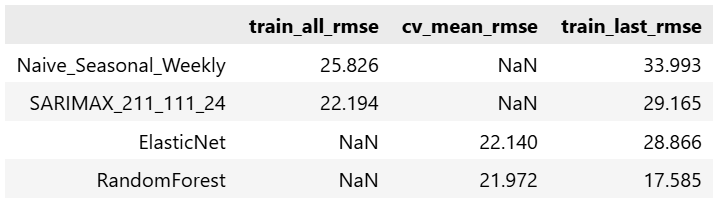

---
По совокупности метрик:
- по метрике RMSE на кросс-валидации/всей train выборке:
  - сопоставимые результаты дали все модели, кроме `Naive_Seasonal_Weekly` у которой метрика хуже остальных трех моделей;
- по метрике RMSE на самых свежих по времени  данных из обучающей выборки (длиной такая же как тестовая выборка):
  - явно выигрывает у прочих `RandomForest`.
 
Итоговый выбор:
- лучшая модель: `RandomForest` имеет лучшие метрики RMSE.

---
***Выводы по тестированию лучшей модели***:
- целевая метрика удовлетворяет условию задания: RMSE = 36.99 < 48;
- структура остатков при прогнозировании относительно неплохая, но не идеальная; при увеличении целевой переменной сверх примерно 180-200 дисперсия остаков растет, точноть прогноза снижается;
- по визуализации прогнозов на тестовой выборке:
  - <u>модель чаще ошибается при прогнозировании высоких/пиковых значений</u> числа заказов (более 180-200 в час);
  - т.е. модель не всегда точно улавливает разовые пиковые выбросы вверх.

***Выводы по важности прознаков***:
- лаговые признаки - наиболее важные для модели;
- самый важный признак: `lag_168` - значение целевой переменной неделю назад (что хорошо согласуется с недельной сезонностью в данных);
- наименее важные признаки: кодированные (через sin/cos) значения дней недели.

***Важные дополнения***:
- CV RMSE=21.97, а Test RMSE=36.99 — разрыв в ~15 единиц - это существенно;
- вероятная причина: в августе (тестовый период) число заказов продолжает расти (есть восходящий тренд в данных), и модель, обученная преимущественно на данных марта–июля, систематически недооценивает пиковые значения;
- это ограничение модели.

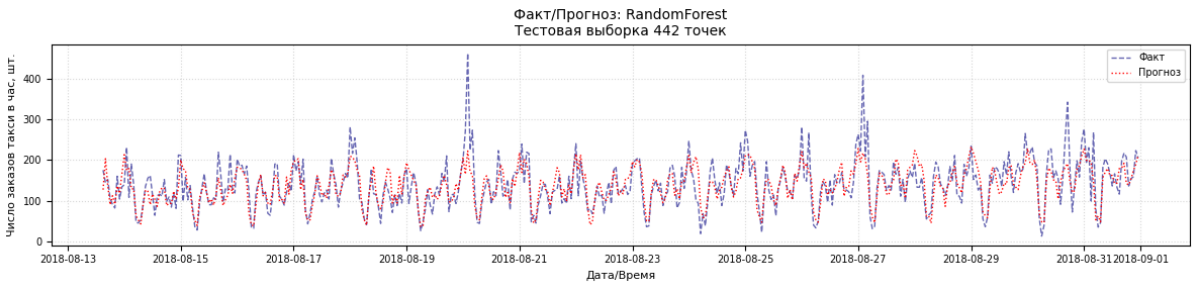

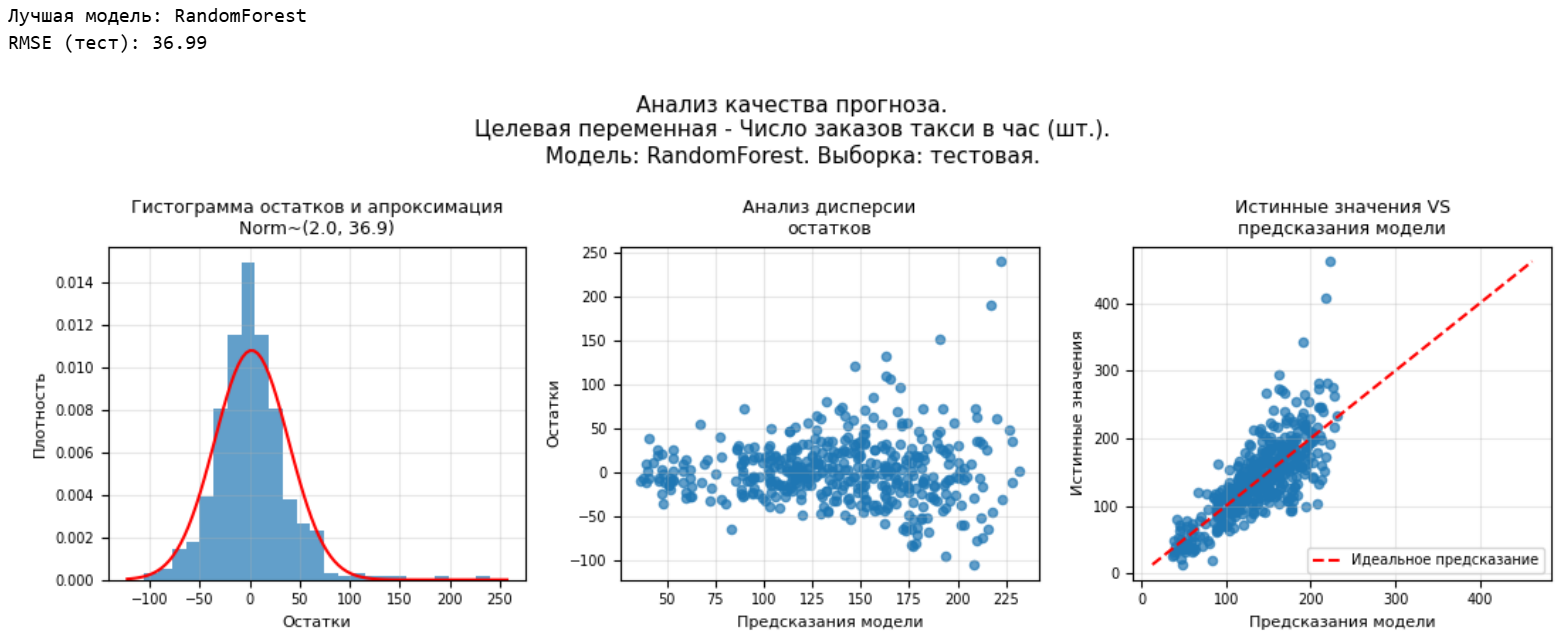

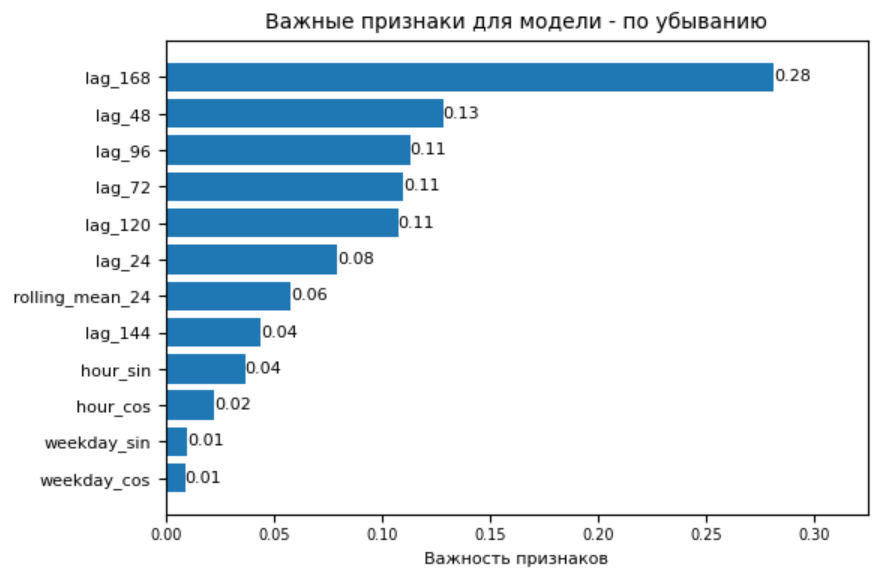